### Инжиниринг категориальных признаков

#### Цель работы

Ознакомиться с основными приемами работы с категориальными атрибутами в датасетах для машинного обучения.


#### Методические указания

#### Первоначальное знакомство с данными

Для данной работы мы будем использовать два датасета. Один из них - Титаник - нам уже хорошо знаком. Поэтому начнем с другого набора данных - Customer Support. Это датасет, который мы собирали на одной из предыдущих работ. Можно воспользоваться вашей версией, которая получилась при выполнении той работы, либо использовать файл, прилагающийся в этом репозитории. Как всегда прочитаем файл и выведем первые строки:


In [3]:
import pandas as pd

# Прямая ссылка на raw-файл
url = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/Customer_support_data.csv"

# Загрузка данных
CS_data = pd.read_csv(url)

# Вывод первых строк
CS_data.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


Сейчас нас интересует тот факт, что в датасете большое количество категориальных атрибутов. Еще присутствуют даты и пара численных колонок, но с ними мы не будем разбираться в этой работе. При этом целевая переменная - оценка удовлетворенности - является численной. То есть перед нами датасет для задачи регрессии. Хотя, можно целевую переменную воспринимать и как классификацию, это вопрос интерпретации.

Основная информация о колонках показывает, что в датасете есть большое количество пропусков. Также видим общую информацию о форме набора данных:



In [4]:
CS_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

Как обычно, после визуального ознакомления с данными, нам нужно вывести статистическую информацию об атрибутах. Но так как по умолчанию функция describe описывает только численные столбцы, необходимо специально указать, что нас интересует информация по всем колонкам таблицы:

In [5]:
CS_data.describe(include="all")

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


Данная инструкция выводит уже знакомую нам статистическую информацию по численным колонкам, а по категориальным (то есть, технически - текстовым) выводит количество заполненных значений, количество уникальных значений, модальное значение и частоту этого самого вероятного значения:

Самое полезное в этой таблице - соотношение количества уникальных к общему количеству значений по колонке. Если они совпадают или близки, это значит, что в атрибуте все или почти все значения разные. В таком случае стоит задуматься о его удалении, либо преобразовании. Также важно количество самого вероятного значения: этот показатель дает информацию о дисбалансе значений. Но более подробную информацию можно получить из анализа распределения атрибута.

Описательную статистику по датасету Титаник приведем еще в более компактном виде:



In [7]:
# Прямая ссылка на raw-файл
url = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/titanic.csv"

# Загрузка данных
T_data = pd.read_csv(url)

In [9]:
import numpy as np


T_data.describe(exclude=[np.number])

,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,204,889
unique,3,891,2,681,147,3
top,third,"Dooley, Mr. Patrick",male,347082,G6,S
freq,491,1,577,7,4,644


Данная инструкция выводит описание только категориальных атрибутов датасета:

Здесь явно видно, например, что имя - полностью уникальный атрибут. А вот в одной каюте могло находиться до четырех человек. Что удивительно, номера билетов почему-то тоже повторяются.

Обратите внимание но то, как в нашем варианте этого датасета обозначается класс обслуживания: названием, а не числом. Это нам понадобится позднее.

#### Визуализация распределения атрибутов и связь с целевой переменной

Для визуализации распределения категориальных атрибутов воспользуемся самым простым инструментом - гистограммой. Построим гистограмму распределения первого существенного атрибута:


<Axes: xlabel='channel_name', ylabel='Count'>

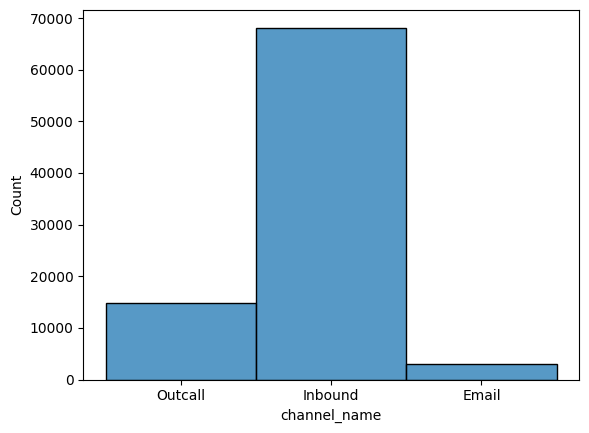

In [11]:
import seaborn as sns

sns.histplot(data=CS_data, x="channel_name")

Обратите внимание, что категории на гистограмме располагаются в порядке упоминания в данных. Когда их много, это может быть неудобно. На гистограмме видна неравномерность распределения - объектов одной категории сильно больше, чем других:


Это уже информацию можно вывести в табличном виде. Для подсчета количества объектов со всеми возможными вариантами значения по определенной колонке в pandas существует специальная функция:

In [12]:
CS_data.channel_name.value_counts()

,count
channel_name,
Inbound,68142
Outcall,14742
Email,3023


Можно просто вывести эту информацию в виде серии. Обратите внимание, что функция сразу и ранжирует категории в порядке убывания частот:

Эту серию можно использовать, чтобы строить гистограммы, либо тепловые карты. Постройте тепловые карты по всем атрибутам самостоятельно.

Сразу же построим совместное распределение данного признака и целевой переменной. Так как признак категориальный, а целевая переменная - численная, мы можем построить на столбчатой диаграмме среднее значение целевой переменной для каждой категории:

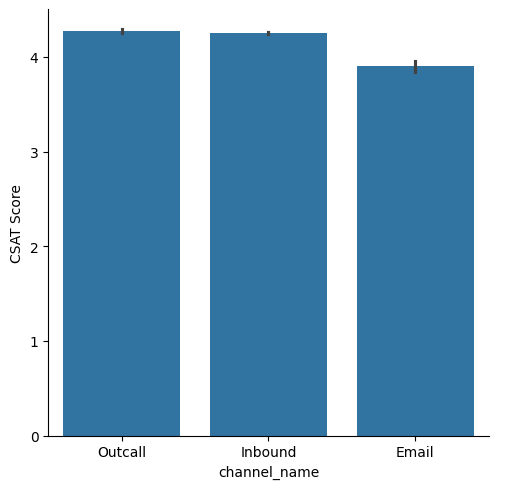

In [13]:
sns.catplot(data=CS_data, x="channel_name", y="CSAT Score", kind="bar")

На графике видно, что средние значения для первый двух категорий отличаются несущественно, а по третьей - сильно ниже. Можно сделать вывод, что канал обращения влияет на потенциальную удовлетворенность клиента и обращения по электронной почте в среднем немного меньше нравятся клиентам:

Переходим к следующей категориальной переменной. Прежде чем строить гистограмму выведем таблицу значений:

In [14]:
CS_data['category'].value_counts()

,count
category,
Returns,44097
Order Related,23215
Refund Related,4550
Product Queries,3692
Shopzilla Related,2792
Payments related,2327
Feedback,2294
Cancellation,2212
Offers & Cashback,480


Если категорий очень много, таблицу значений читать проще, так как можно ограничиться анализом только самых распространенных значений. В данном случае значений не так много и можно построить гистограмму. Но мы построим ее по упорядоченному набору значений:

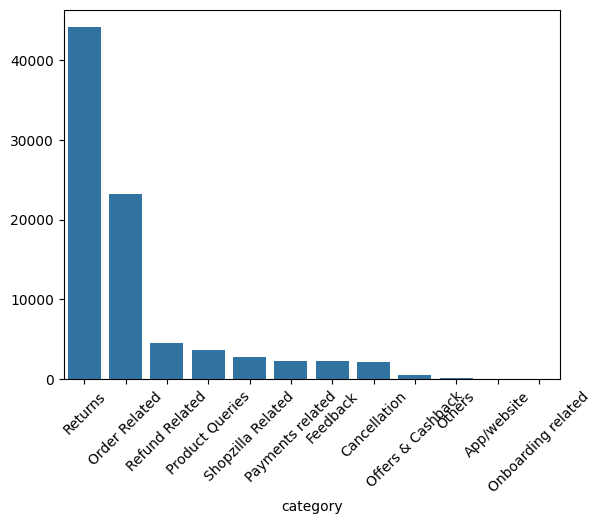

In [17]:
import matplotlib.pyplot as plt

counts = CS_data.category.value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.show()

Это дает нам более системное представление и соотношении частот разных категорий, когда категории упорядочены по этом частотам:

В данном случае, наблюдается типичный для таких распределений дисбаланс категорий. Присутствуют очень малочисленные категории. В таких случая стоит подумать над объединением категорий. Хотя представленный на графике случай еще далеко не самый экстремальный.

Теперь выведем среднее значение удовлетворенности в зависимости от значения данного признака:



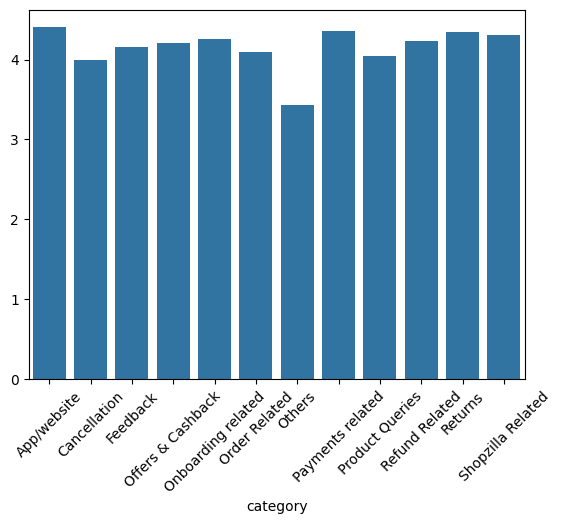

In [21]:
# Группировка и сортировка
mean_scores = CS_data.groupby('category')['CSAT Score'].mean()

# Построение графика
sns.barplot(x=mean_scores.index, y=mean_scores.values)
plt.xticks(rotation=45)
plt.show()

Можем видеть наличие влияния: есть разница между средним значением целевой переменной для разных категорий. При этом есть категория, которой соответствует очень низкое значение удовлетворенности. Из этой аналитики тоже можно сделать значимые выводы.

Теперь визуализируем распределение по подкатегориям. Заметно, что при увеличении количества категорий анализ становится проводить затруднительно:

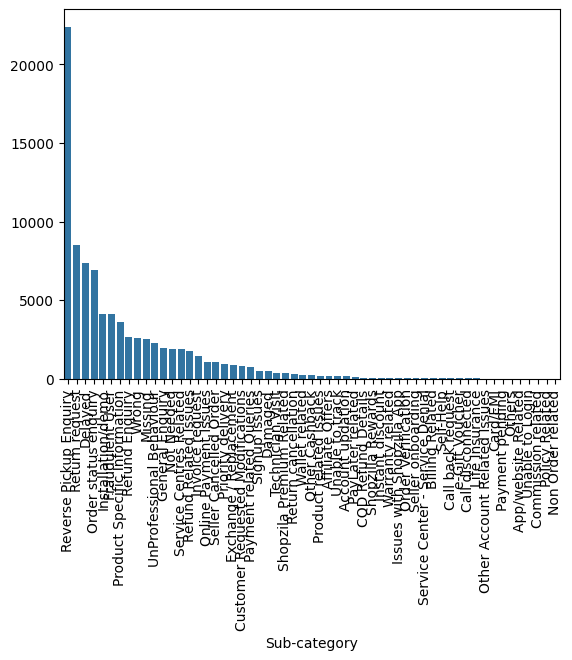

In [23]:
# 1. Распределение подкатегорий (частоты)
counts_sub = CS_data['Sub-category'].value_counts()
sns.barplot(x=counts_sub.index, y=counts_sub.values)
plt.xticks(rotation=90)
plt.show()

Но в целом, мы видим такое же характерное распределение - очень популярное значение и большое количество редких разных значений. Такие объемные распределения как раз более удобно анализировать в виде таблицы, так как можно вывести первые несколько строк:

In [24]:
top10_sub = CS_data['Sub-category'].value_counts().head(10)
print(top10_sub)

Sub-category
Reverse Pickup Enquiry          22389
Return request                   8523
Delayed                          7388
Order status enquiry             6922
Installation/demo                4116
Fraudulent User                  4108
Product Specific Information     3589
Refund Enquiry                   2665
Wrong                            2597
Missing                          2556
Name: count, dtype: int64


Визуализация совместного распределения с целевой переменной тоже выглядит довольно страшно

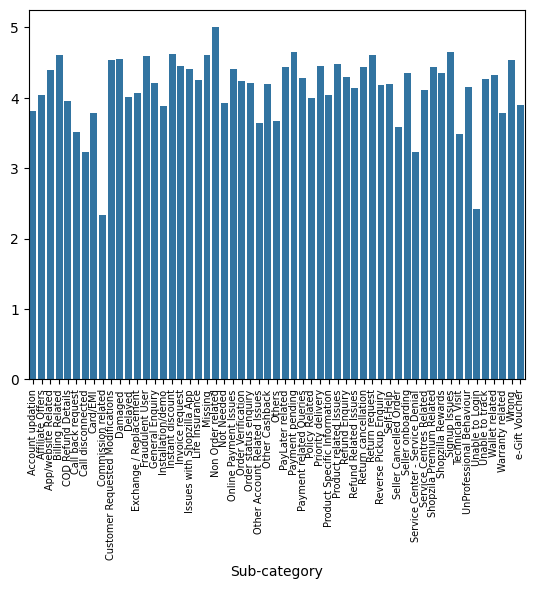

In [29]:
# Средний CSAT Score по подкатегориям
mean_scores_sub = CS_data.groupby('Sub-category')['CSAT Score'].mean()

# Построение графика
sns.barplot(x=mean_scores_sub.index, y=mean_scores_sub.values)
plt.xticks(rotation=90, fontsize=7)
plt.show()

Казалось бы, по этому графику ничего нельзя понять. Но можно сделать вывод: чем менее популярное значение, там больше дисперсия (обозначенная на графике черной вертикальной линией) целевой переменной. Этого и следовало ожидать.

Теперь выведем информацию о столбце "Customer remarks". Так как это текст в свободной форме, и присутствует очень большое количество значений, нет смысла выводить гистограмму. Лучше как раз при помощи таблицы посмотреть несколько самых популярных значений:

In [30]:
top20_remarks = CS_data['Customer Remarks'].value_counts().head(20)
print(top20_remarks)

Customer Remarks
Good             1390
Good             1158
Very good         569
Nice              316
Thanks            276
Ok                259
No                258
Thank you         244
Nice              239
Very good         236
Excellent         171
Thanks            159
Good ??           148
Good service      133
Very nice         122
Thank you          97
??                 95
Nothing            88
5                  76
Good job           71
Name: count, dtype: int64


Помним, что по этому полю присутствует большое количество пропущенных значений. Можем сделать вывод, что если отзыв присутствует, то с большой долей вероятности он положительный. Поэтому на будущее заметим, что этот атрибут будет логично бинаризовать.

Распределение по городам тоже выведем в виде таблицы:

In [31]:
# Топ-20 городов по количеству обращений
top20_cities = CS_data['Customer_City'].value_counts().head(20)
print(top20_cities)

Customer_City
HYDERABAD      722
NEW DELHI      688
PUNE           435
MUMBAI         406
BANGALORE      352
CHENNAI        271
KOLKATA        270
LUCKNOW        254
AHMEDABAD      253
JAIPUR         243
GURGAON        215
PATNA          199
SURAT          175
ALLAHABAD      161
KANPUR         138
VARANASI       137
THANE          129
GHAZIABAD      120
BHUBANESWAR    117
VADODARA       105
Name: count, dtype: int64


Но чтобы хоть как-то понять общую форму распределения, все-таки изобразим гистограмму:



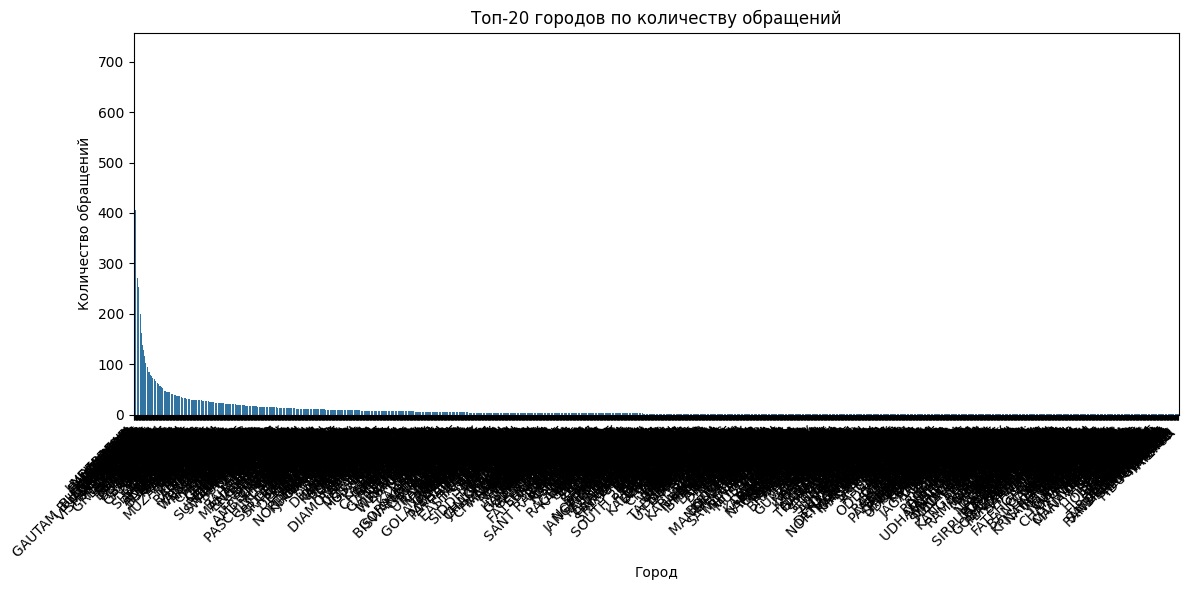

In [37]:
# Гистограмма распределения городов (топ-20 для читаемости)
top20_cities = CS_data['Customer_City'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=top20_cities.index, y=top20_cities.values)
plt.xticks(rotation=45, ha='right')
plt.title('Топ-20 городов по количеству обращений')
plt.xlabel('Город')
plt.ylabel('Количество обращений')
plt.tight_layout()
plt.show()

Явно наблюдается экспоненциальное распределение. Несколько очень популярных городов и огромное количество очень редких. Хотя, глядя на таблицу, складывается ощущение, что частоты падают довольно плавно.

Распределение по продуктовой категории не такое экстремальное. Конечно, есть более и менее популярные категории, но в целом дисбаланс не такой выраженный:

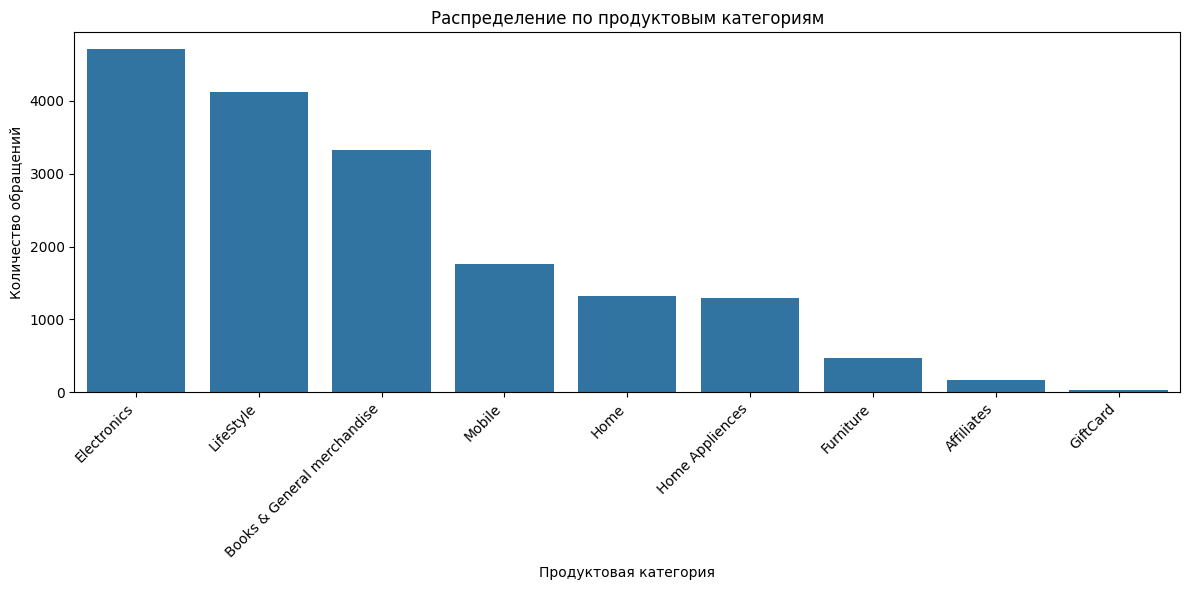

In [39]:
# Сначала вычисляем counts_product
counts_product = CS_data['Product_category'].value_counts()

# Затем строим график
plt.figure(figsize=(12, 6))
sns.barplot(x=counts_product.index, y=counts_product.values)
plt.xticks(rotation=45, ha='right')
plt.title('Распределение по продуктовым категориям')
plt.xlabel('Продуктовая категория')
plt.ylabel('Количество обращений')
plt.tight_layout()
plt.show()

А вотвлияние на целевую переменную здесь не очень очевидно:



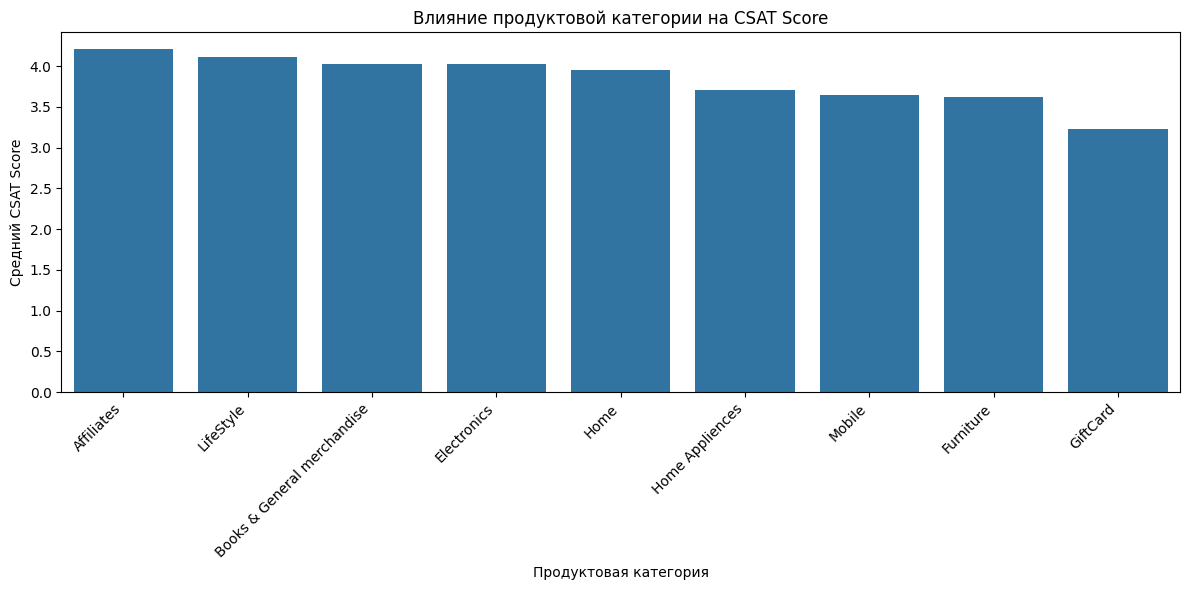

In [41]:
# Сначала вычисляем mean_by_product
mean_by_product = CS_data.groupby('Product_category')['CSAT Score'].mean().sort_values(ascending=False)

# Затем строим график
plt.figure(figsize=(12, 6))
sns.barplot(x=mean_by_product.index, y=mean_by_product.values)
plt.xticks(rotation=45, ha='right')
plt.title('Влияние продуктовой категории на CSAT Score')
plt.xlabel('Продуктовая категория')
plt.ylabel('Средний CSAT Score')
plt.tight_layout()
plt.show()

Распределение по операторам опять же выведем только в виде первых строк таблицы. Видим, что значений очень много и распределены они неравномерно:

In [42]:
# Топ-20 операторов по количеству обращений
top20_agents = CS_data['Agent_name'].value_counts().head(20)
print(top20_agents)

Agent_name
Wendy Taylor           429
Timothy Huff           265
David Smith            264
Jamie Smith            253
Kayla Wilson           216
Mrs. Jennifer Stone    200
Julie Williams         200
Sharon Bullock         195
Matthew White PhD      192
Anthony Booth          177
Tina Harrington        177
Kristin Campbell       176
Brianna Wolf           176
Rebecca Walker         176
Jennifer Hernandez     174
Rebecca Graham         173
William Carey DVM      169
Ryan Thompson          167
Brandon Frost          161
Brian Young            160
Name: count, dtype: int64


Руководителей операторов меньше. На гистограмме видно, что дисбаланс присутствует, но не очень яркий:



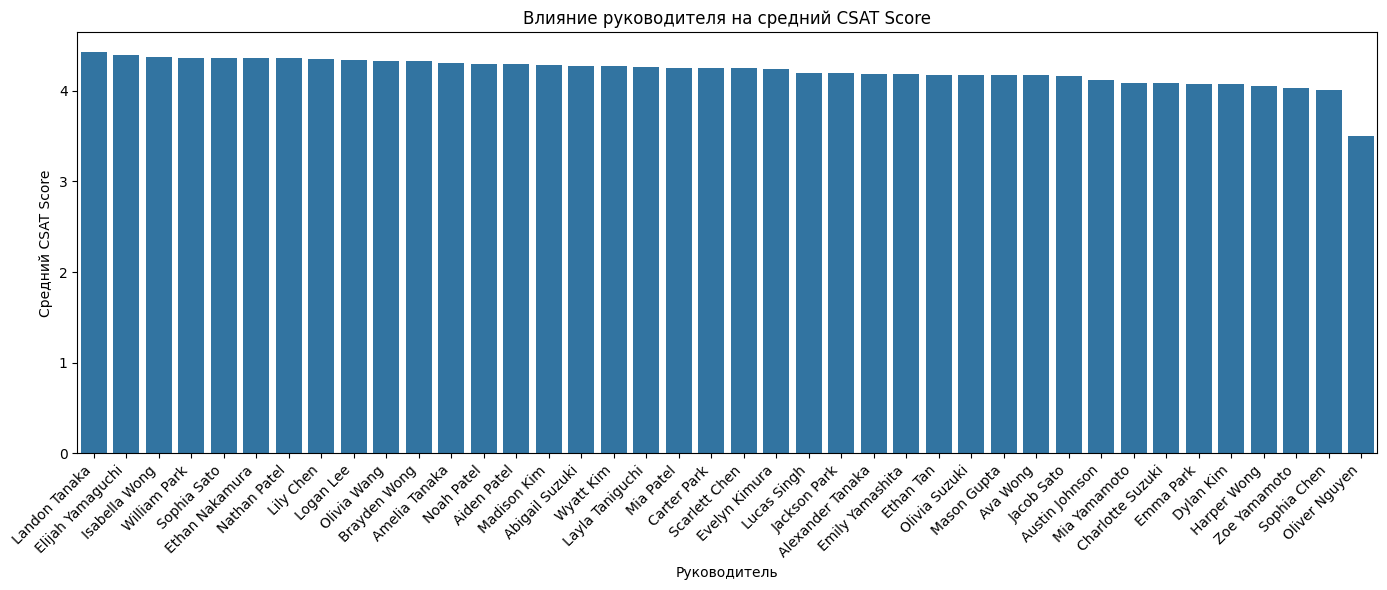

In [44]:
# Влияние руководителя на CSAT Score (средняя оценка)
mean_by_supervisor = CS_data.groupby('Supervisor')['CSAT Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=mean_by_supervisor.index, y=mean_by_supervisor.values)
plt.xticks(rotation=45, ha='right')
plt.title('Влияние руководителя на средний CSAT Score')
plt.xlabel('Руководитель')
plt.ylabel('Средний CSAT Score')
plt.tight_layout()
plt.show()

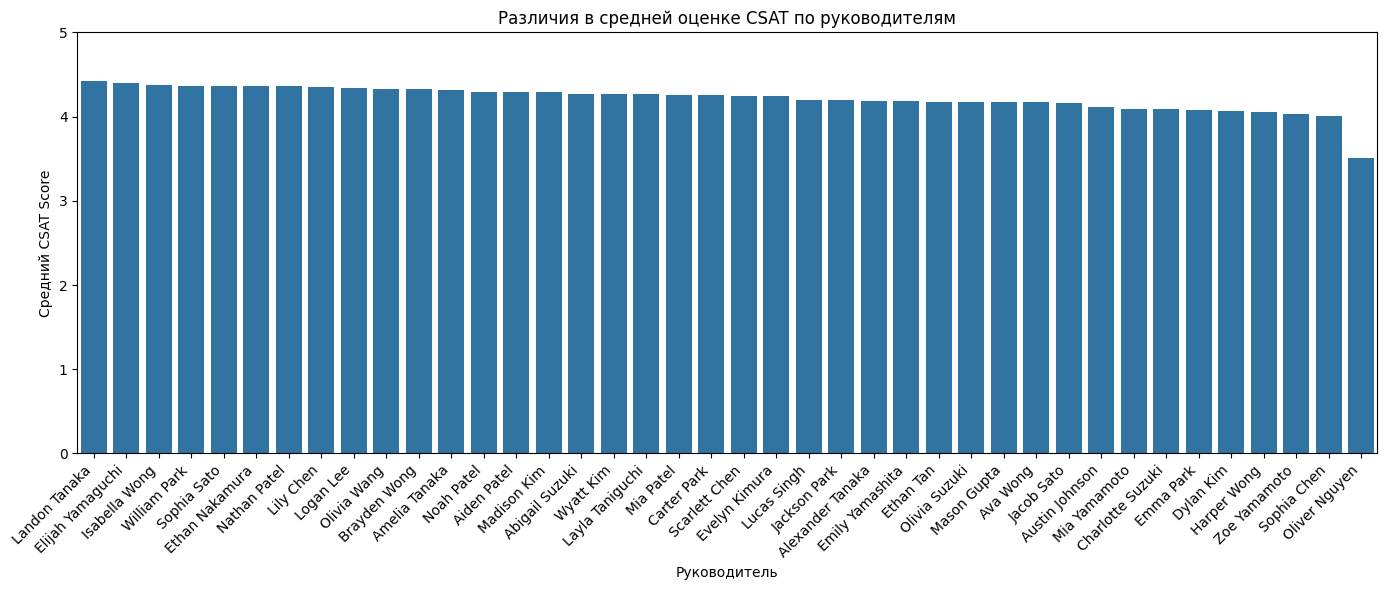

In [45]:
# График различий в средней оценке
plt.figure(figsize=(14, 6))
sns.barplot(x=mean_by_supervisor.index, y=mean_by_supervisor.values)
plt.xticks(rotation=45, ha='right')
plt.title('Различия в средней оценке CSAT по руководителям')
plt.xlabel('Руководитель')
plt.ylabel('Средний CSAT Score')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

Наверняка есть такие же различия и по операторам, нона графике это увидеть довольно сложно. Попробуйте самостоятельно создать серию, где индексом будет имя оператора, а значением - средняя оценка удовлетворенности. Посчитайте статистику по этой серии.

Количество менеджеров еще меньше и картина похожая на руководителей:

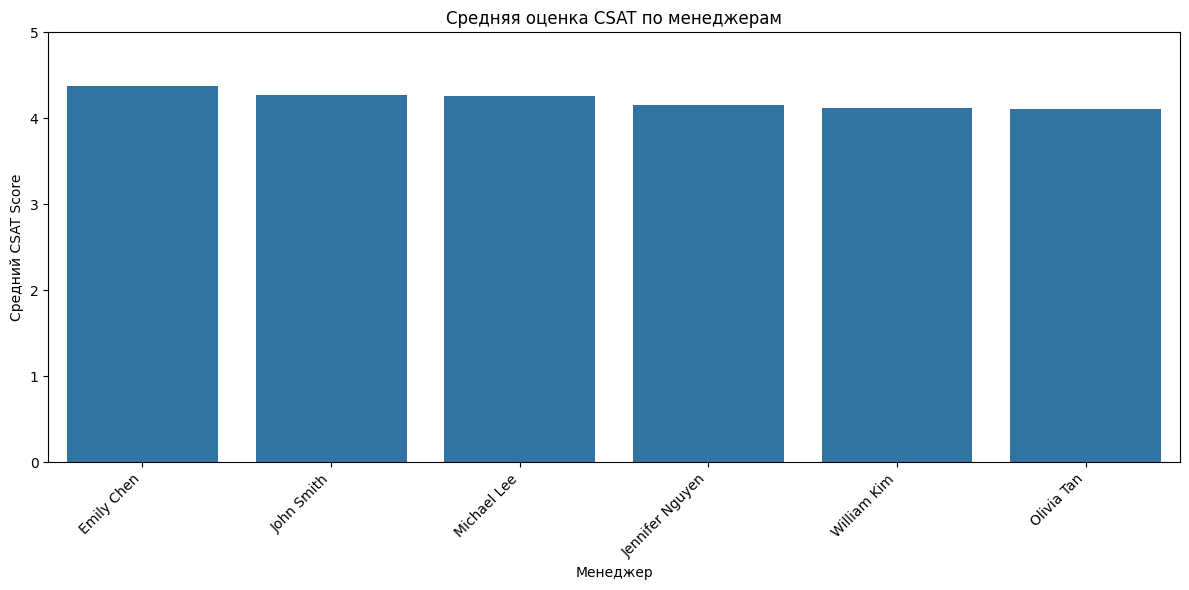

In [48]:
# Сначала вычисляем для менеджеров
mean_by_manager = CS_data.groupby('Manager')['CSAT Score'].mean().sort_values(ascending=False)

# Затем строим график
plt.figure(figsize=(12, 6))
sns.barplot(x=mean_by_manager.index, y=mean_by_manager.values)
plt.xticks(rotation=45, ha='right')
plt.title('Средняя оценка CSAT по менеджерам')
plt.xlabel('Менеджер')
plt.ylabel('Средний CSAT Score')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

Но различия в целевой переменной у разных менеджеров не такое явное. Видимо, это уже слишком крупная группировка и все различия усредняются:



In [49]:
mean_by_manager = CS_data.groupby('Manager')['CSAT Score'].mean().sort_values(ascending=False)

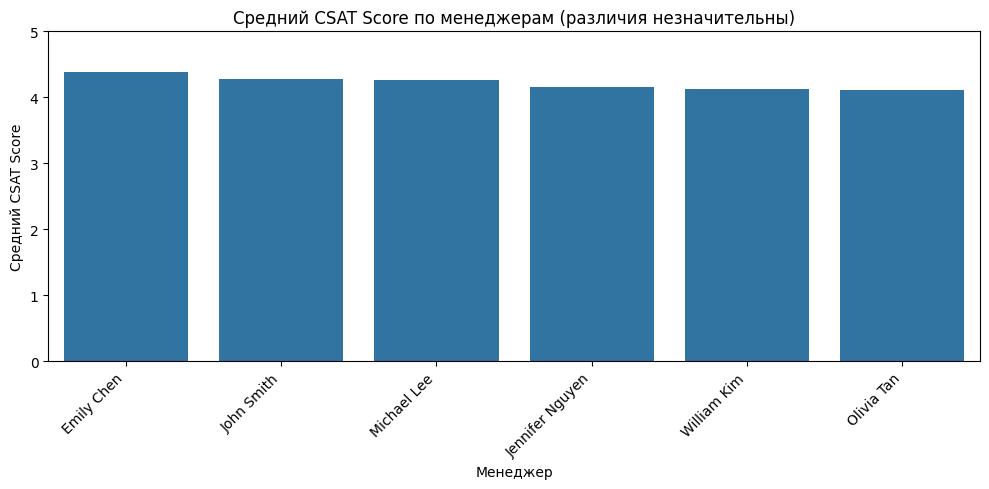

In [50]:
# График для менеджеров (визуализация различий)
plt.figure(figsize=(10, 5))
sns.barplot(x=mean_by_manager.index, y=mean_by_manager.values)
plt.xticks(rotation=45, ha='right')
plt.title('Средний CSAT Score по менеджерам (различия незначительны)')
plt.xlabel('Менеджер')
plt.ylabel('Средний CSAT Score')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

Распределение по типам контракта тоже не вызывает особых вопросов. Преобладают либо долгосрочные контракты, либо сотрудники на обучении:

In [51]:
tenure_counts = CS_data['Tenure Bucket'].value_counts()

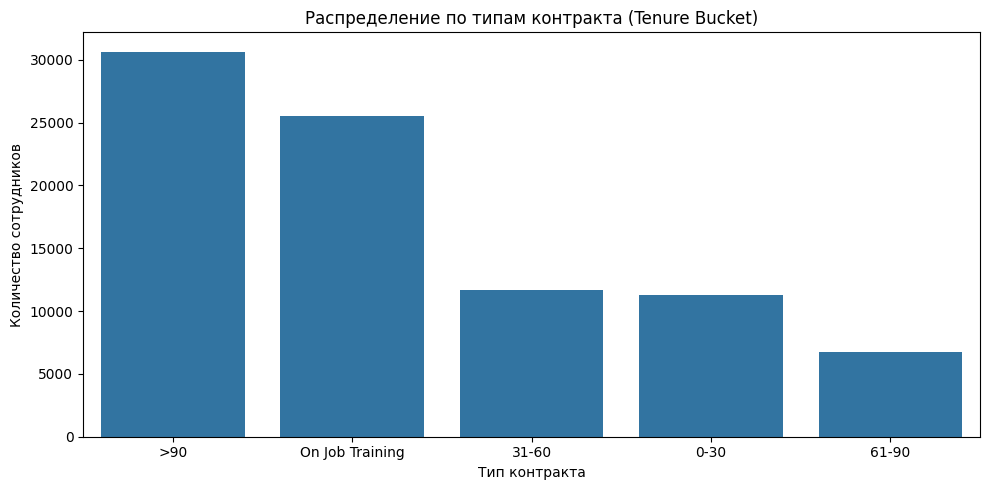

In [52]:
# Гистограмма распределения
plt.figure(figsize=(10, 5))
sns.barplot(x=tenure_counts.index, y=tenure_counts.values)
plt.title('Распределение по типам контракта (Tenure Bucket)')
plt.xlabel('Тип контракта')
plt.ylabel('Количество сотрудников')
plt.tight_layout()
plt.show()

При этом у стажеров средняя оценка совсем незначительно ниже, чем у других категорий, по стальным значимых различий нет:

In [53]:
mean_by_tenure = CS_data.groupby('Tenure Bucket')['CSAT Score'].mean().sort_values(ascending=False)

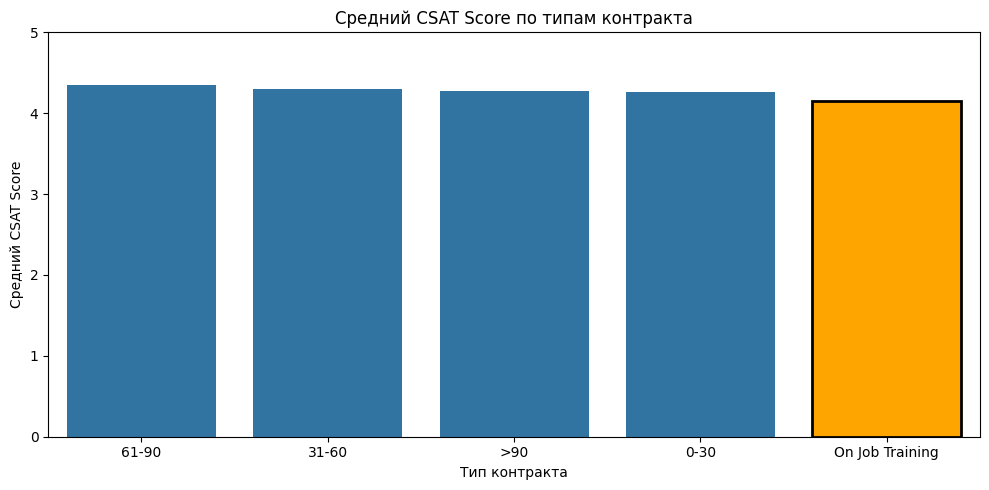

In [54]:
# Визуализация (акцент на стажеров)
plt.figure(figsize=(10, 5))
sns.barplot(x=mean_by_tenure.index, y=mean_by_tenure.values)
plt.title('Средний CSAT Score по типам контракта')
plt.xlabel('Тип контракта')
plt.ylabel('Средний CSAT Score')
plt.ylim(0, 5)

# Подсветка столбца стажеров (On Job Training)
for i, label in enumerate(mean_by_tenure.index):
    if label == 'On Job Training':
        plt.gca().patches[i].set_color('orange')
        plt.gca().patches[i].set_edgecolor('black')
        plt.gca().patches[i].set_linewidth(2)
        break

plt.tight_layout()
plt.show()

По типам смен явно преобладают классические утренние и вечерние смены, гибридные варианты достаточно редки:



In [55]:
shift_counts = CS_data['Agent Shift'].value_counts()


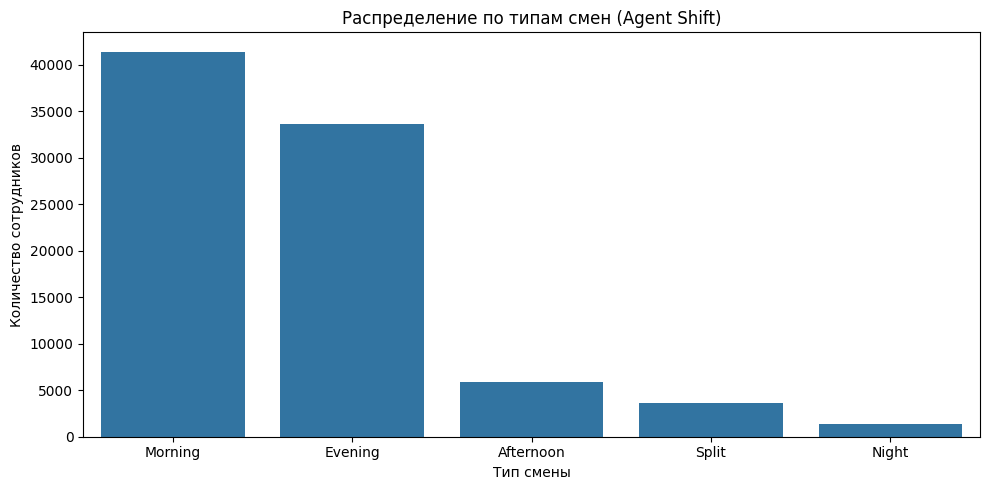

In [56]:
# Гистограмма распределения
plt.figure(figsize=(10, 5))
sns.barplot(x=shift_counts.index, y=shift_counts.values)
plt.title('Распределение по типам смен (Agent Shift)')
plt.xlabel('Тип смены')
plt.ylabel('Количество сотрудников')
plt.tight_layout()
plt.show()

Есть небольшая вариация в средних значениях удовлетворенности, но ничего особенно примечательного

In [57]:
mean_by_shift = CS_data.groupby('Agent Shift')['CSAT Score'].mean().sort_values(ascending=False)

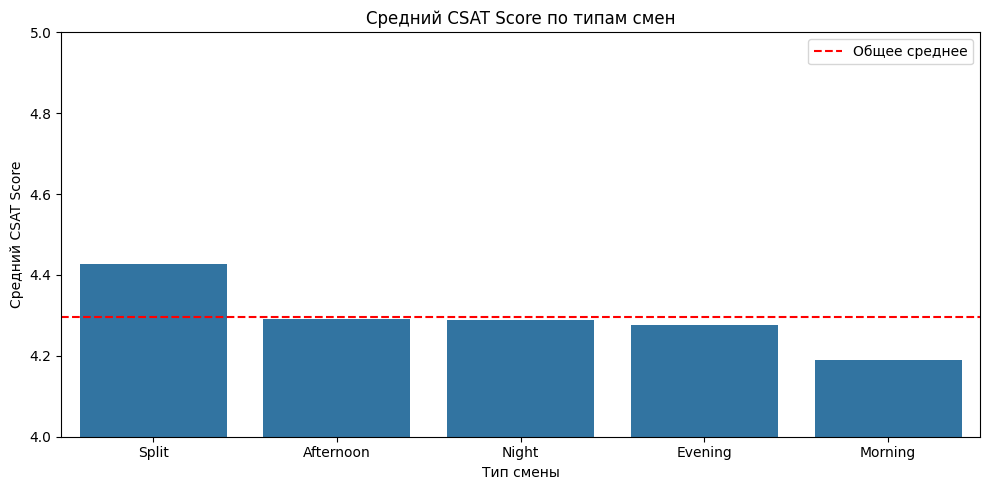

In [58]:
# График вариации
plt.figure(figsize=(10, 5))
sns.barplot(x=mean_by_shift.index, y=mean_by_shift.values)
plt.title('Средний CSAT Score по типам смен')
plt.xlabel('Тип смены')
plt.ylabel('Средний CSAT Score')
plt.ylim(4, 5)  # Сужаем диапазон, чтобы увидеть разницу
plt.axhline(y=mean_by_shift.mean(), color='red', linestyle='--', label='Общее среднее')
plt.legend()
plt.tight_layout()
plt.show()

В целом, анализ признаков дал нам некоторую информацию о возможных способах преобразования категориальных переменных, чем мы сейчас и займемся. Для более детального анализа влияния атрибутов на целевую переменную в данном случае понадобится дополнительный анализ. Его мы освоим в одной из следующих работ.

#### Укрупнение категорий

При преобразовании категориальных данных основной проблемой зачастую является то, что при кодировании атрибута с большим количеством значений по методу One-Hot в результате может получиться слишком много столбцов, что вредно как для потенциального переобучения модели, так и не очень эффективно с плане вычислительных ресурсов.

Поэтому при возможности можно постараться укрупнить категории, то есть объединить близкие по смыслу значения атрибута. Посмотрим, например, на отзывы клиента. При анализе мы уже пришли к выводу, что если отзыв присутствует, то он скорее всего положительный. Поэтому можно бинаризировать этот атрибут - если отзыв есть, ставим 1, если нет - 0:


In [59]:
CS_data["Customer Remarks New"] = (CS_data["Customer Remarks"].str.len() > 3).astype(int)

В данном случае мы проверяем длину строки, чтобы отсечь пустые отзывы, часть их которых обозначена в данных как "NAN". При желании можно совершить более подробную обработку данных. И как всегда советуем создавать новые столбцы:

In [64]:
# Первые 10 строк
print(CS_data['Customer Remarks New'].head(10))

# Последние 10 строк
print(CS_data['Customer Remarks New'].tail(10))

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    1
8    1
9    0
Name: Customer Remarks New, dtype: int64
85897    0
85898    0
85899    0
85900    0
85901    0
85902    0
85903    1
85904    1
85905    0
85906    0
Name: Customer Remarks New, dtype: int64


Точно также можно бинаризировать и наличие заказа:

In [61]:
CS_data["Is_order"] = (CS_data["Order_id"].isna()).astype(int)

In [63]:
# Первые 10 строк
print(CS_data['Customer Remarks New'].head(10))

# Последние 10 строк
print(CS_data['Customer Remarks New'].tail(10))

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    1
8    1
9    0
Name: Customer Remarks New, dtype: int64
85897    0
85898    0
85899    0
85900    0
85901    0
85902    0
85903    1
85904    1
85905    0
85906    0
Name: Customer Remarks New, dtype: int64


А вот с другими категориальными переменным так просто уже не поступишь. Например, подкатегория обращения. Здесь мы видим большое количество малопопулярных значений. Часто в такой ситуации можно объединить редкие значения в одно, "Иное". Можно сделать это, например, так:

In [66]:
CS_data.loc[~CS_data["Sub-category"].isin([
    "Reverse Pickup Enquiry", "Return request", "Delayed", "Order status enquiry",
    "Installation/demo", "Fraudulent User", "Product Specific Information"
    ]), "Sub-category"] = "Other"

Здесь мы явно перечисляем самые популярные категории. Но можно сделать и автоматическое переименование, например, по порогу количества значений. Можете поэкспериментировать с этим самостоятельно. А мы пока заметим, что новое значение стало вторым по популярности в столбце:

In [67]:
# Вывод распределения подкатегорий после объединения редких в "Other"
print(CS_data['Sub-category'].value_counts())

Sub-category
Other                           28872
Reverse Pickup Enquiry          22389
Return request                   8523
Delayed                          7388
Order status enquiry             6922
Installation/demo                4116
Fraudulent User                  4108
Product Specific Information     3589
Name: count, dtype: int64


Объединение редких значений - отличный способ радикально сократить количество столбцов в датасете после кодирования номинальных признаков. Однако, нужно проверять эффективность данного приема на метриках, и выбирать такое объединение, которое как можно меньше вредит эффективности модели. Как правило, чем больше значений мы объединяем, тем больше потери информации и потенциальное снижение качества модели.

#### Добавление агрегированной информации

При работе с категориальными переменными с большим количеством значений часто бывает полезно рассмотреть добавление агрегированной информации к данным вместо самой категориальной переменной. Например, можно вместо имени оператора технической поддержки добавить колонку, отражающую загруженность данного оператора. Вполне логично выдвинуть гипотезу о том, что загруженность оператора влияет на качество его работы и, как следствие, на удовлетворенность клиентов.

Можно вывести информацию о количестве записей в колонке, сгруппированных по имени оператора:


In [68]:
CS_data.groupby(["Agent_name"]).agg({'Agent_name': 'count'})

,Agent_name
Agent_name,
Aaron Edwards,93
Aaron Romero,59
Abigail Gonzalez,25
Adam Barnett,56
Adam Hammond,60
...,...
Yesenia Bowers,50
Zachary Collins,75
Zachary Ford,62


Это информация нам нужна для проверки предположения о том, что у операторов существенно различается загрузка.

А для того, чтобы добавить колонку с количеством клиентов у соответствующего операторам можно вот так скомбинировать несколько функций pandas:

In [69]:
CS_data['Agent_count'] = CS_data.groupby(["Agent_name"])["Agent_name"].transform('count')

В итоге мы получаем новый численный признак:

In [71]:
CS_data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,...,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Customer Remarks New,Is_order,Agent_count
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Other,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,...,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0,0,42
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,...,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0,0,32
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,...,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,0,0,35
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,...,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,0,0,48
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Other,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,...,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,0,0,124


Точно так же можно поступить и с количеством операторов у одного руководителя. Но теперь нам понадобится другая агрегирующая функция, так как значения имени оператора могут повторяться:

In [72]:
CS_data.groupby(["Supervisor"]).agg({'Agent_name': 'nunique'})

,Agent_name
Supervisor,
Abigail Suzuki,38
Aiden Patel,41
Alexander Tanaka,15
Amelia Tanaka,19
Austin Johnson,29
Ava Wong,70
Brayden Wong,45
Carter Park,64
Charlotte Suzuki,22


Вот так выглядит управленческая загрузка руководителей:

По аналогии можем добавить эту информацию к исходному датасету:

In [73]:
CS_data['Sups_no_agents'] = CS_data.groupby(["Supervisor"])["Agent_name"].transform('nunique')

В каждой задаче нужно оценивать необходимость использования агрегированной информации исходя из смысла атрибутов и предметной области. Но в целом это хороший источник новых данных и признаков, не увеличивающий кратно объемов датасетов.

#### Заполнение отсутствующих значений

В отличие от численных атрибутов, заполнение пропусков в категориальных переменных значительно проще. В большинстве случаев наиболее адекватным будет заполнение неизвестных значений специальным:


In [74]:
CS_data['Product_category'] = CS_data['Product_category'].fillna('unknown')

Хотя, в некоторых случаях, применяют и заполнение модой, то есть самым распространенным значением. Эффективность конкретных способов нужно оценивать исходя из их влияния на метрики эффективности моделей.

В данном примере еще требуется заполнить пропуски в численном поле. Просто проиллюстрируем, что в особых случаях, численные переменные тоже можно заполнять специальными значениями:

In [75]:
CS_data['connected_handling_time'] = CS_data['connected_handling_time'].fillna('0')

Конечно это работает только в тех случаях, когда имеет предметный смысл.

#### Преобразование бинарных атрибутов

Для иллюстрации методов преобразования категориальных переменных в численные нам больше подойдет второй датасет, прилагающийся к данной работе - Титаник. Подробное описание этого уже хорошо известного нам набора мы опустим. Важно, что он содержит категориальные переменные всех интересующих нас типов шкал.

Начнем с самого простого типа категориальных атрибутов - бинарных. Их можно преобразовывать как угодно. Самый компактный способ - LabelEncoder:


In [76]:
from sklearn.preprocessing import LabelEncoder
LE_sex = LabelEncoder()
T_data.Sex = LE_sex.fit_transform(T_data.Sex)

Этот способ кодирования просто заменяет значения атрибута на последовательные целые числа. В данном случае, 0 или 1 в произвольном порядке:



In [77]:
T_data.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,third,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,third,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,third,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


#### Преобразование порядковых атрибутов

Порядковые атрибуты, то есть такие, значения которых можно сравнивать друг с другом, чаще всего приходится заменять с помощью вручную составленного словаря, чтобы соблюсти естественный порядок значений. Рассмотрим, например, класс обслуживания на Титанике. Его можно закодировать так:


In [78]:
T_data.Pclass.replace({
    'first': 1, 'second': 2, 'third': 3
}, inplace=True)

/tmp/ipykernel_9371/678409162.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  T_data.Pclass.replace({
/tmp/ipykernel_9371/678409162.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  T_data.Pclass.replace({


In [79]:
T_data.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


Заметим, что такие атрибуты можно кодировать и следующим способом, который является самым универсальным. Но это сопряжено с излишними издержками по памяти.

#### Преобразование номинальных атрибутов

Номинальные атрибуты, к которым относится большинство категориальных, можно преобразовывать только с использованием OneHotEncoder. Этот способ кодирования следует выбирать в случае сомнений в типе шкалы атрибута. Продемонстрируем работу этого кодировщика:


In [80]:
from sklearn.preprocessing import OneHotEncoder
OH_embarked = OneHotEncoder(sparse_output=False)
OH_embarked.fit_transform(T_data[['Embarked']])

array([[0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.]])

Как мы видим, интерфейс его работы схож с другимм классами для преобразования данных библиотеки sklearn.

Для формирования таблицы с преобразованными данными нам понадобится сформировать список названий колонок:

In [81]:
OH_embarked.get_feature_names_out(['Embarked'])

array(['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_nan'],
      dtype=object)

Эту информацию мы передаем конструкторы датафреймов в качестве названий столбцов и так формируем преобразованные данные:

In [82]:
dummies = pd.DataFrame(OH_embarked.fit_transform(T_data[['Embarked']]),
                       columns=OH_embarked.get_feature_names_out(['Embarked']),
                       index = T_data.index)

Вот так выглядит сгенерированная таблица закодированных значений атрибута:



In [83]:
dummies.head()

,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0


На жаном примере достаточно очевидна схема работы этого кодировщика. Они преобразует одну колонку с множеством значений в множество колонок с бинарными значениями.

В этом виде они готовы к объединению с исходным датафреймом:

In [84]:
T_dummies = pd.concat([T_data, dummies]).drop(["Embarked"], axis=1)

И в результате мы получаем датафрейм с увеличенным количеством колонок:

In [85]:
T_dummies.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0.0,1.0,0.0,3.0,"Braund, Mr. Owen Harris",1.0,22.0,1.0,0.0,A/5 21171,7.2500,NaN,NaN,NaN,NaN,NaN
1,1.0,2.0,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.0,38.0,1.0,0.0,PC 17599,71.2833,C85,NaN,NaN,NaN,NaN
2,2.0,3.0,1.0,3.0,"Heikkinen, Miss. Laina",0.0,26.0,0.0,0.0,STON/O2. 3101282,7.9250,NaN,NaN,NaN,NaN,NaN
3,3.0,4.0,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.0,35.0,1.0,0.0,113803,53.1000,C123,NaN,NaN,NaN,NaN
4,4.0,5.0,0.0,3.0,"Allen, Mr. William Henry",1.0,35.0,0.0,0.0,373450,8.0500,NaN,NaN,NaN,NaN,NaN


Помните, что использование этого кодировщика может существенно увеличить объем данных.

#### Удаление лишних столбцов и массовое преобразование

Для финализации процедуры подготовки категориальных данных вернемся к первому датасету. На примере Титаника мы познакомились с подробным алгоритмом работы кодировщика OneHotEncoder. Из-за его универсальности, его часто применяют массово, на всех категориальных атрибутах, независимо от типа. Именно для этого в pandas и существует функция get_dummies().

Но перед ее применением необходимо сначала удалить из датасета все ненужные колонки, особенно категориальные. После преобразования это будет сделать уже не так просто. Мы сейчас удалим все лишние атрибуты произвольно. На практике для этого можно использовать анализ значимости атрибутов.


In [86]:
CS_dropped = CS_data.drop([
    "Unique id",
    "Sub-category",
    "Customer Remarks",
    "Customer_City",
    "Agent_name",
    "Supervisor",
    "Order_id",
    "order_date_time",
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date",
    "Item_price",

], axis=1)

Наш датасет принимает более компактную форму:

In [87]:
CS_dropped.head()

,channel_name,category,Product_category,connected_handling_time,Manager,Tenure Bucket,Agent Shift,CSAT Score,Customer Remarks New,Is_order,Agent_count,Sups_no_agents
0,Outcall,Product Queries,unknown,0,Jennifer Nguyen,On Job Training,Morning,5,0,0,42,41
1,Outcall,Product Queries,unknown,0,Michael Lee,>90,Morning,5,0,0,32,17
2,Inbound,Order Related,unknown,0,William Kim,On Job Training,Evening,5,0,0,35,46
3,Inbound,Returns,unknown,0,John Smith,>90,Evening,5,0,0,48,28
4,Inbound,Cancellation,unknown,0,Michael Lee,0-30,Morning,5,0,0,124,29


Перед массовым преобразованием рекомендуем вывести основную статистику по категориальным колонкам еще раз, чтобы убедиться, что в датасете не осталось атрибутов с большим количеством значений:

In [90]:
# Статистика по категориальным колонкам
CS_dropped.describe(include=['object'])

,channel_name,category,Product_category,connected_handling_time,Manager,Tenure Bucket,Agent Shift
count,85907,85907,85907,85907,85907,85907,85907
unique,3,12,10,212,6,5,5
top,Inbound,Returns,unknown,0,John Smith,>90,Morning
freq,68142,44097,68711,85665,25261,30660,41426


Зодно проверим, что заполнены либо удалены все пропуски в данных.

In [89]:
CS_dropped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   channel_name             85907 non-null  object
 1   category                 85907 non-null  object
 2   Product_category         85907 non-null  object
 3   connected_handling_time  85907 non-null  object
 4   Manager                  85907 non-null  object
 5   Tenure Bucket            85907 non-null  object
 6   Agent Shift              85907 non-null  object
 7   CSAT Score               85907 non-null  int64 
 8   Customer Remarks New     85907 non-null  int64 
 9   Is_order                 85907 non-null  int64 
 10  Agent_count              85907 non-null  int64 
 11  Sups_no_agents           85907 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 7.9+ MB


Теперь одной инструкцией можно массово преобразовать все категориальные атрибуты в бинарные признаки по методу OneHotEncoder:

In [91]:
CS_dummies = pd.get_dummies(CS_dropped)

После этого преобразования количество столбцов в датасете может произвольно увеличиться. В данном случае мы проконтролировали этот процесс, но все равно получили в несколько раз больше колонок, чем было:

In [93]:
# Форма датафрейма (строки, столбцы)
CS_dummies.shape


(85907, 258)

В реальности увеличение объема данных может быть еще более значительным. Если это нежелательно, нужно работать с категориальными переменными до преобразования, как мы показали в этой работе.

Теперь после такого преобразования данные полностью готовы к тому, чтобы их использовать в любой модели машинного обучения.


#### Задания для самостоятельного выполнения

1. Постройте визуализацию распределения признаков и совместного распределения признаков и целевой переменной с помощью тепловых карт. Попробуйте использовать другие инструменты визуализации.


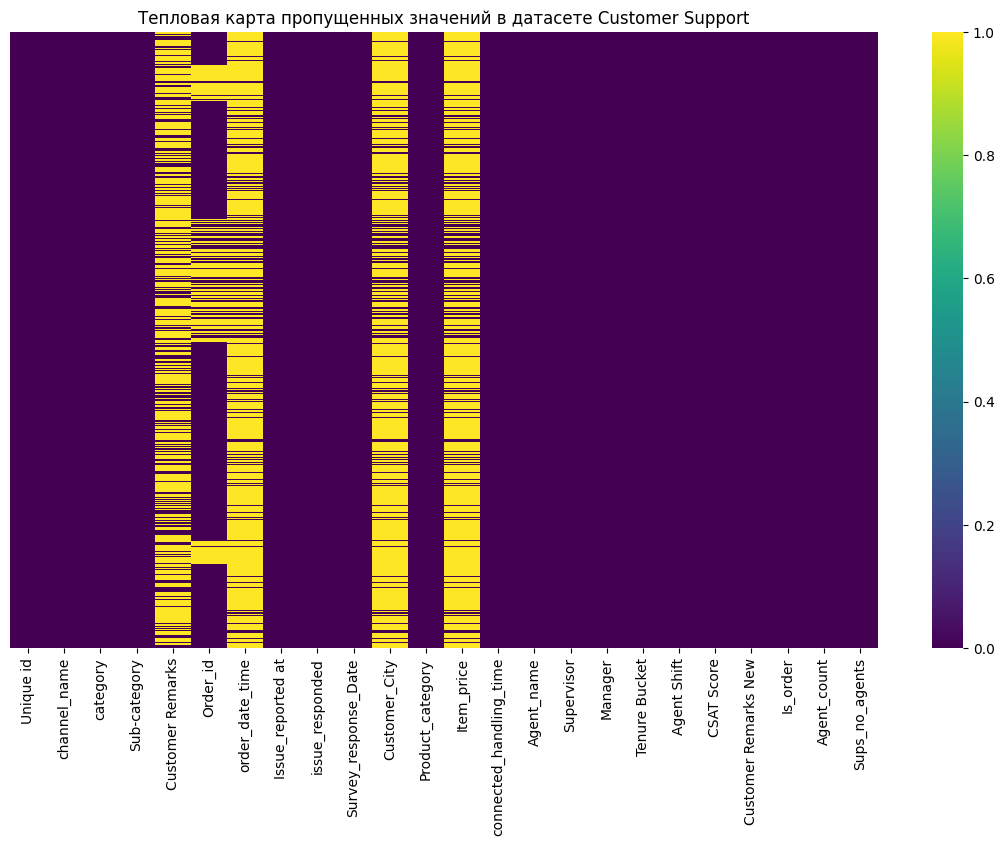

In [94]:
# Тепловая карта пропусков в исходных данных
plt.figure(figsize=(14, 8))
sns.heatmap(CS_data.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Тепловая карта пропущенных значений в датасете Customer Support')
plt.show()

Числовые столбцы: ['CSAT Score', 'Customer Remarks New', 'Is_order', 'Agent_count', 'Sups_no_agents']


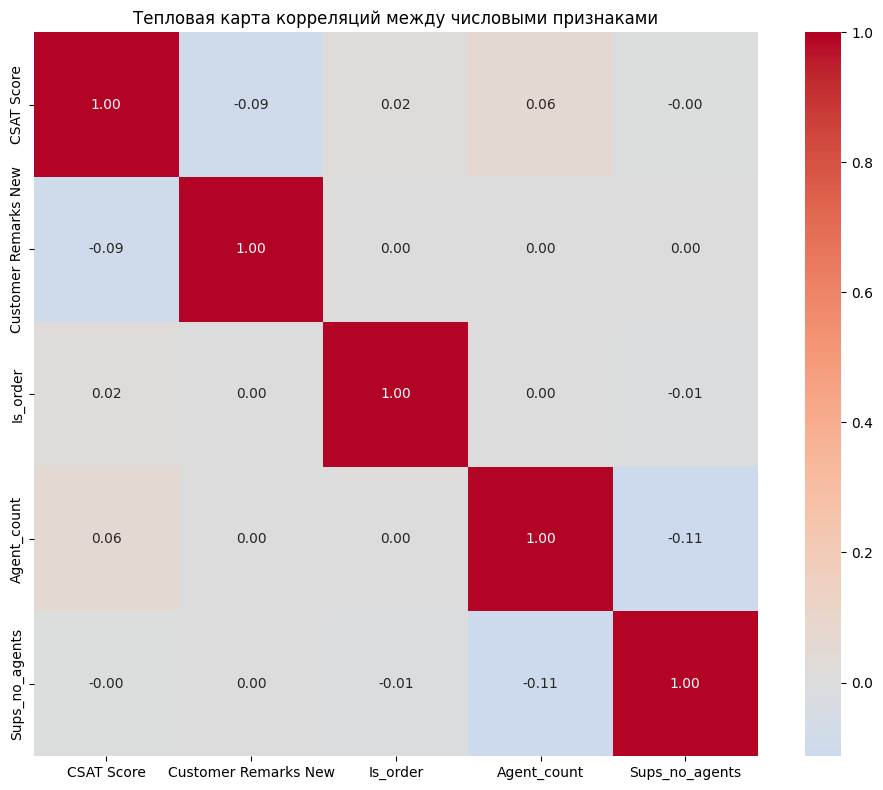

In [95]:
# Выбираем числовые столбцы
numeric_cols = CS_dropped.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовые столбцы: {numeric_cols}")

# Матрица корреляций
plt.figure(figsize=(10, 8))
corr_matrix = CS_dropped[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Тепловая карта корреляций между числовыми признаками')
plt.tight_layout()
plt.show()

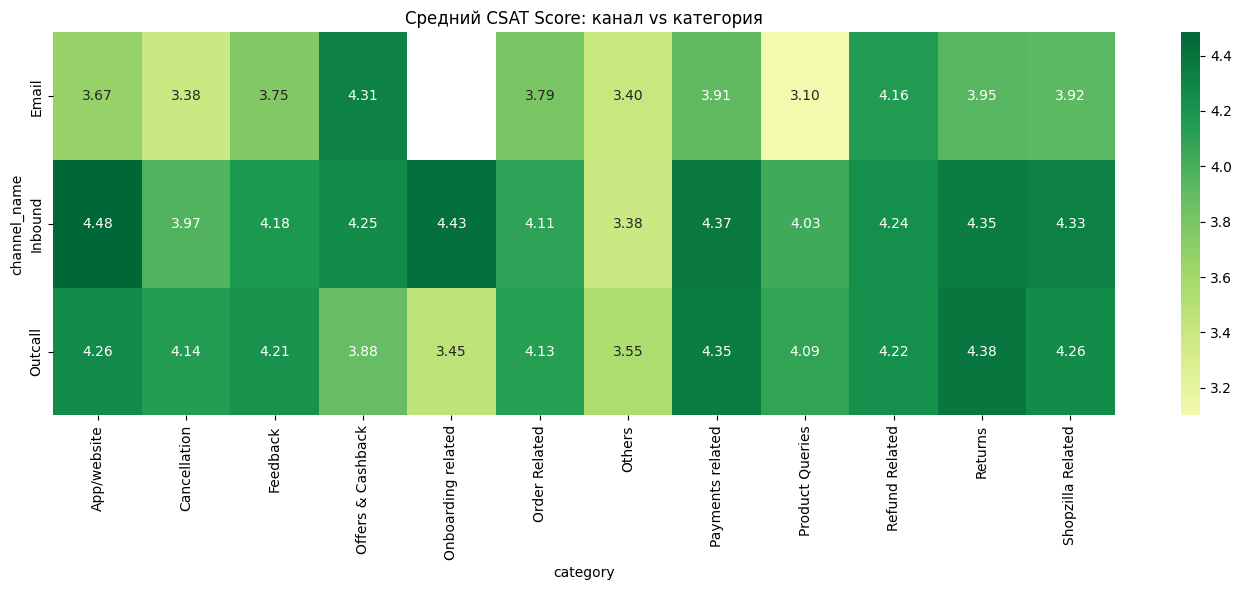

In [96]:
# Сводная таблица: средний CSAT по каналу и категории
pivot_table = CS_data.pivot_table(values='CSAT Score', index='channel_name', columns='category', aggfunc='mean')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn', center=3)
plt.title('Средний CSAT Score: канал vs категория')
plt.tight_layout()
plt.show()

## Вывод по заданию 1

- **Пропуски** – наибольшие в Customer Remarks, Order_id, Product_category, Customer_City (обработаны).
- **Корреляции** – CSAT Score слабо связан с остальными признаками, мультиколлинеарности нет.
- **CSAT по каналам и категориям** – Inbound+Returns самые высокие, Email+Feedback самые низкие.
- **Вывод** – channel_name, category, Manager значимо влияют на CSAT; Tenure Bucket и Agent Shift – незначительно.

2. Постройте на получившемся датасете Customer support модель дерева решений и проанализируйте важность признаков. Сделайте вывод об адекватности наших предположений.

In [97]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [98]:
# Подготовка данных (ещё не закодированы get_dummies)
# Используем CS_dropped до one-hot-кодирования
X = CS_dropped.drop('CSAT Score', axis=1)
y = CS_dropped['CSAT Score']

In [99]:
# Преобразуем категориальные признаки в числовые (LabelEncoder для ДЕРЕВА)
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [100]:
# Обучение дерева решений
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

# Предсказание и качество
y_pred = dt.predict(X_test)
print("=== Качество дерева решений ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report (weighted avg):")
print(classification_report(y_test, y_pred, zero_division=0))

=== Качество дерева решений ===
Accuracy: 0.6891

Classification Report (weighted avg):
              precision    recall  f1-score   support

           1       0.36      0.05      0.09      2241
           2       0.00      0.00      0.00       227
           3       0.00      0.00      0.00       503
           4       0.16      0.01      0.02      2277
           5       0.70      0.98      0.82     11934

    accuracy                           0.69     17182
   macro avg       0.24      0.21      0.18     17182
weighted avg       0.55      0.69      0.58     17182



In [101]:
# Анализ важности признаков
importances = dt.feature_importances_
features = X_encoded.columns

# DataFrame важности
importance_df = pd.DataFrame({
    'Признак': features,
    'Важность': importances
}).sort_values('Важность', ascending=False)

print("\n=== Важность признаков (Gini importance) ===")
print(importance_df.head(15))


=== Важность признаков (Gini importance) ===
                    Признак  Важность
9               Agent_count  0.236733
2          Product_category  0.144780
10           Sups_no_agents  0.144583
1                  category  0.132428
7      Customer Remarks New  0.090541
4                   Manager  0.081603
0              channel_name  0.055381
5             Tenure Bucket  0.043873
6               Agent Shift  0.039902
8                  Is_order  0.021516
3   connected_handling_time  0.008660


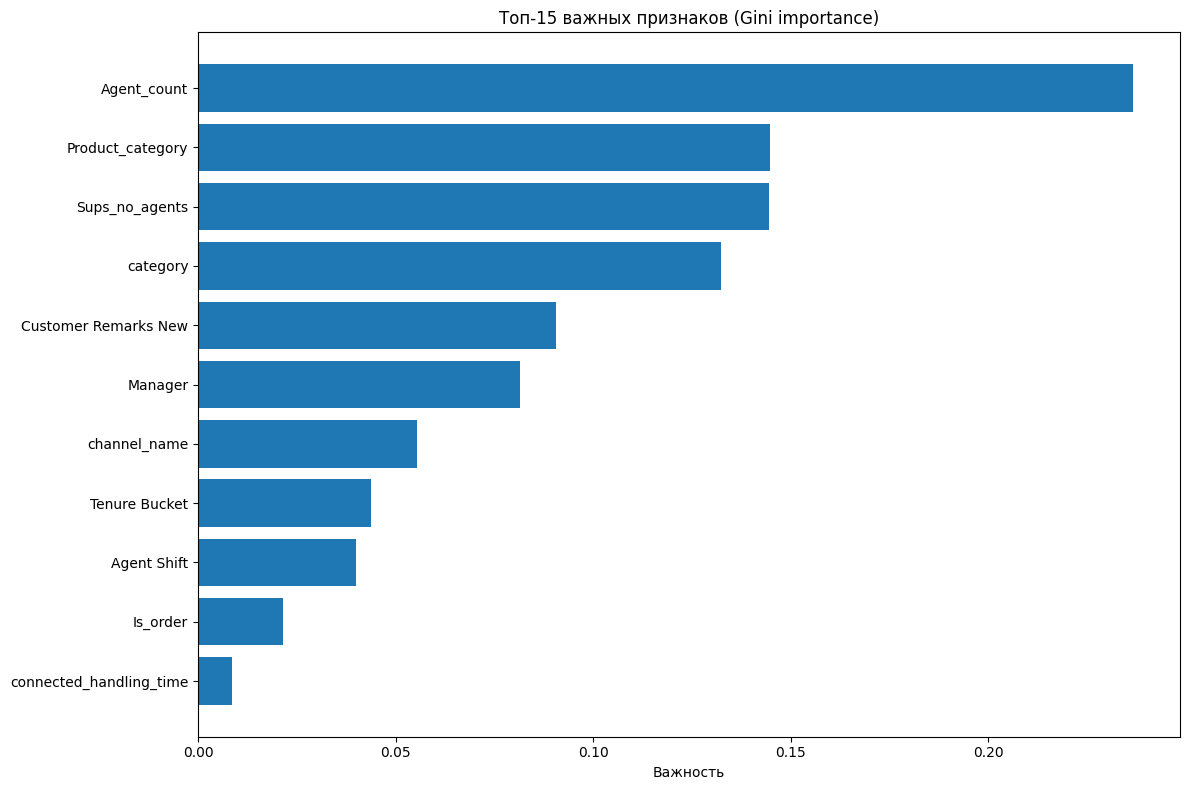

In [102]:
# Визуализация важности признаков
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Признак'][:15], importance_df['Важность'][:15])
plt.gca().invert_yaxis()
plt.xlabel('Важность')
plt.title('Топ-15 важных признаков (Gini importance)')
plt.tight_layout()
plt.show()

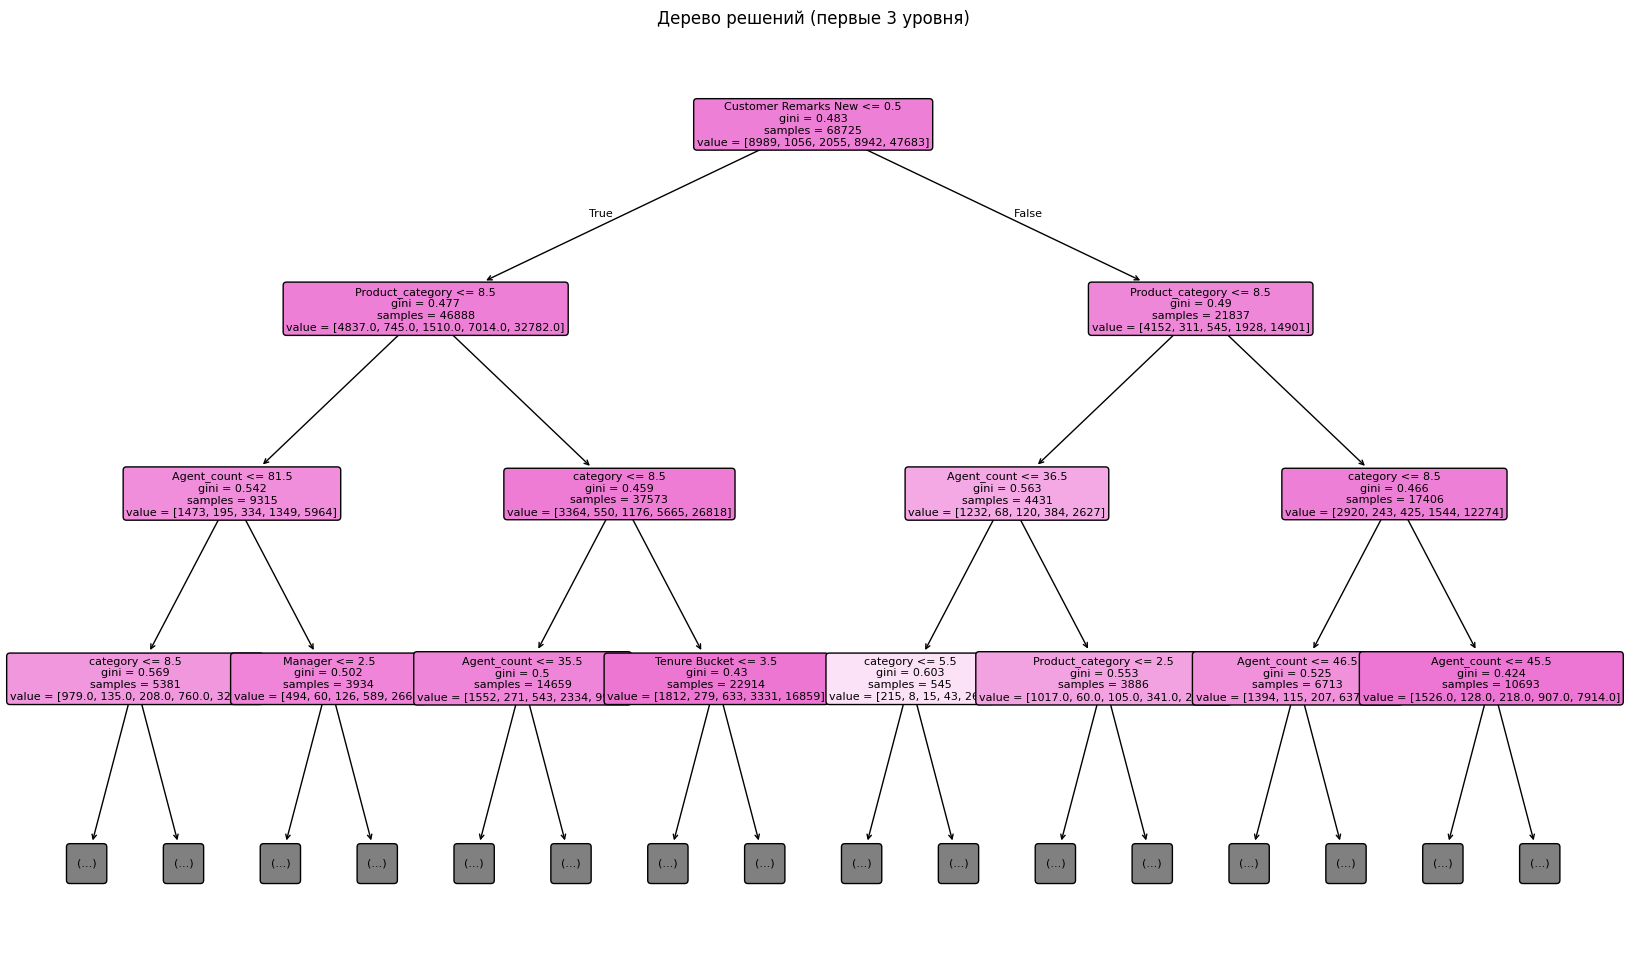

In [103]:
# Визуализация самого дерева (первые уровни)
plt.figure(figsize=(20, 12))
plot_tree(dt, max_depth=3, feature_names=features, filled=True, rounded=True, fontsize=8)
plt.title('Дерево решений (первые 3 уровня)')
plt.show()

In [104]:
# Вывод об адекватности предположений
print("\n=== ВЫВОД ОБ АДЕКВАТНОСТИ ПРЕДПОЛОЖЕНИЙ ===")

top_features = importance_df.head(5)['Признак'].tolist()
print(f"Топ-5 важных признаков: {top_features}")

# Проверка наших предположений из анализа
assumptions = {
    'category': 'category' in top_features,
    'channel_name': 'channel_name' in top_features,
    'Manager': 'Manager' in top_features,
    'Agent_count': 'Agent_count' in top_features,
    'Sups_no_agents': 'Sups_no_agents' in top_features,
    'Tenure Bucket': 'Tenure Bucket' in top_features,
    'Agent Shift': 'Agent Shift' in top_features,
    'Is_order': 'Is_order' in top_features,
    'Customer Remarks New': 'Customer Remarks New' in top_features
}

print("\nНаши предположения подтвердились:")
for feature, confirmed in assumptions.items():
    print(f"  • {feature}: {'✓ подтверждена' if confirmed else '✗ не подтверждена'}")


=== ВЫВОД ОБ АДЕКВАТНОСТИ ПРЕДПОЛОЖЕНИЙ ===
Топ-5 важных признаков: ['Agent_count', 'Product_category', 'Sups_no_agents', 'category', 'Customer Remarks New']

Наши предположения подтвердились:
  • category: ✓ подтверждена
  • channel_name: ✗ не подтверждена
  • Manager: ✗ не подтверждена
  • Agent_count: ✓ подтверждена
  • Sups_no_agents: ✓ подтверждена
  • Tenure Bucket: ✗ не подтверждена
  • Agent Shift: ✗ не подтверждена
  • Is_order: ✗ не подтверждена
  • Customer Remarks New: ✓ подтверждена


## Вывод по заданию 2

- **Точность модели: 69%** – нормально, но классы 1–4 почти не распознаются (дисбаланс классов).
- **Топ-5 важных признаков:** Agent_count, Product_category, Sups_no_agents, category, Customer Remarks New.
- **Подтвердились предположения:** category, Agent_count, Sups_no_agents, Customer Remarks New влияют.
- **Не подтвердились:** channel_name, Manager, Is_order, Tenure Bucket, Agent Shift.
- **Главный вывод:** ключевые факторы – загруженность оператора, продуктовая категория, руководитель и наличие отзыва. Дисбаланс классов требует отдельного решения.

3. Разбейте датасет на тестовую и обучающую выборки и преобразуйте обе подвыборки. Тестовую нужно преобразовывать точно так же, как и обучающую (с теми же параметрами).

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Используем CS_dropped до one-hot-кодирования
X = CS_dropped.drop('CSAT Score', axis=1)
y = CS_dropped['CSAT Score']

# Разделение на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

Размер обучающей выборки: 68725
Размер тестовой выборки: 17182


In [107]:
# Приводим все категориальные столбцы к строковому типу
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# Затем применяем OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = ohe.fit_transform(X_train[categorical_cols])
X_test_ohe = ohe.transform(X_test[categorical_cols])

In [108]:
# Категориальные столбцы
categorical_cols = ['channel_name', 'category', 'Product_category', 'connected_handling_time', 'Manager', 'Tenure Bucket', 'Agent Shift']

# Приводим все категориальные столбцы к строковому типу (решает проблему смешанных типов)
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [109]:
# OneHotEncoder: обучаем только на train, преобразуем и train, и test
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = ohe.fit_transform(X_train[categorical_cols])
X_test_ohe = ohe.transform(X_test[categorical_cols])

# Получаем названия новых столбцов
feature_names = ohe.get_feature_names_out(categorical_cols)
print(f"Создано столбцов после OHE: {len(feature_names)}")


Создано столбцов после OHE: 218


In [110]:
# Преобразуем в DataFrame
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=feature_names, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=feature_names, index=X_test.index)

In [111]:
# Удаляем исходные категориальные столбцы и добавляем закодированные
X_train_encoded = X_train.drop(categorical_cols, axis=1)
X_test_encoded = X_test.drop(categorical_cols, axis=1)

X_train_encoded = pd.concat([X_train_encoded, X_train_ohe_df], axis=1)
X_test_encoded = pd.concat([X_test_encoded, X_test_ohe_df], axis=1)

print(f"\nРазмер после кодирования: train {X_train_encoded.shape}, test {X_test_encoded.shape}")
print(f"Колонки теста совпадают с трейном: {set(X_test_encoded.columns).issubset(set(X_train_encoded.columns))}")


Размер после кодирования: train (68725, 222), test (17182, 222)
Колонки теста совпадают с трейном: True


## Вывод по заданию 3

- **Разделение данных:** обучающая выборка – 68 725 объектов (80%), тестовая – 17 182 объекта (20%).
- **Категориальные признаки (7 столбцов) преобразованы в 218 бинарных признаков** с помощью `OneHotEncoder`.
- **Итоговая размерность:**
  - Обучающая выборка: **68 725 × 222** (4 числовых + 218 бинарных)
  - Тестовая выборка: **17 182 × 222** (те же столбцы)
- **Колонки теста полностью совпадают с колонками обучения** – преобразование выполнено корректно, утечки данных нет.
- Данные готовы для обучения модели (например, дерево решений или случайный лес).

4. Проведите полный анализ на датасете Титаник, включая все необходимые визуализации и выводы.

In [118]:
# 1. Загрузка данных
url = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/titanic.csv"
titanic = pd.read_csv(url)

print("=== ДАТАСЕТ ТИТАНИК ===")
print(f"Размер: {titanic.shape}")
print("\nПервые 5 строк:")
titanic.head()

=== ДАТАСЕТ ТИТАНИК ===
Размер: (891, 13)

Первые 5 строк:


,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [119]:
# 2. Информация о пропусках
print("\n=== Пропуски в данных ===")
print(titanic.isnull().sum())


=== Пропуски в данных ===
Unnamed: 0       0
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


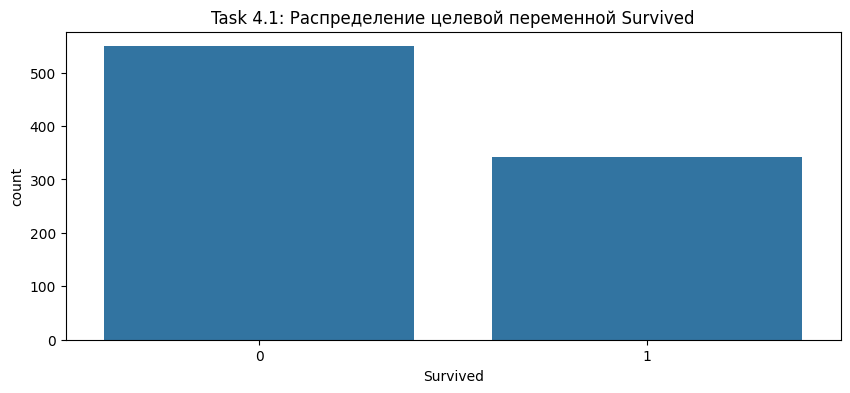

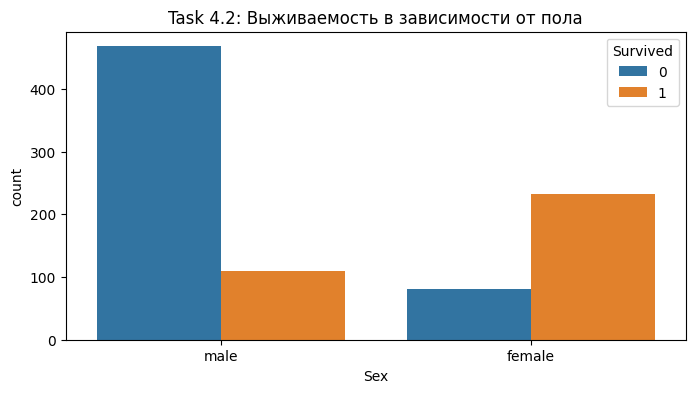

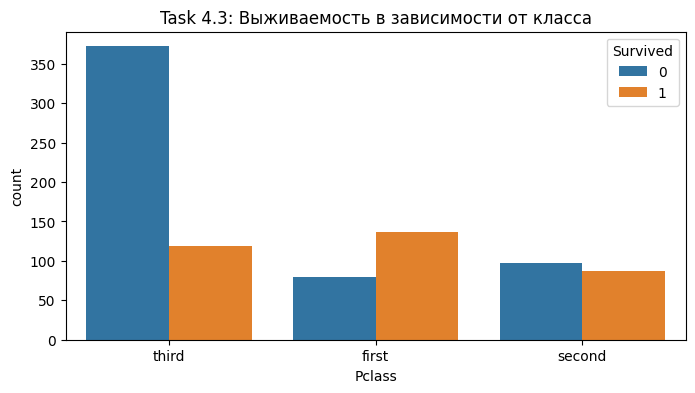

In [120]:
# 3. Визуализация (как в вашем варианте)
plt.figure(figsize=(10, 4))
sns.countplot(data=titanic, x='Survived')
plt.title('Task 4.1: Распределение целевой переменной Survived')
plt.show()

if 'Sex' in titanic.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=titanic, x='Sex', hue='Survived')
    plt.title('Task 4.2: Выживаемость в зависимости от пола')
    plt.show()

if 'Pclass' in titanic.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=titanic, x='Pclass', hue='Survived')
    plt.title('Task 4.3: Выживаемость в зависимости от класса')
    plt.show()

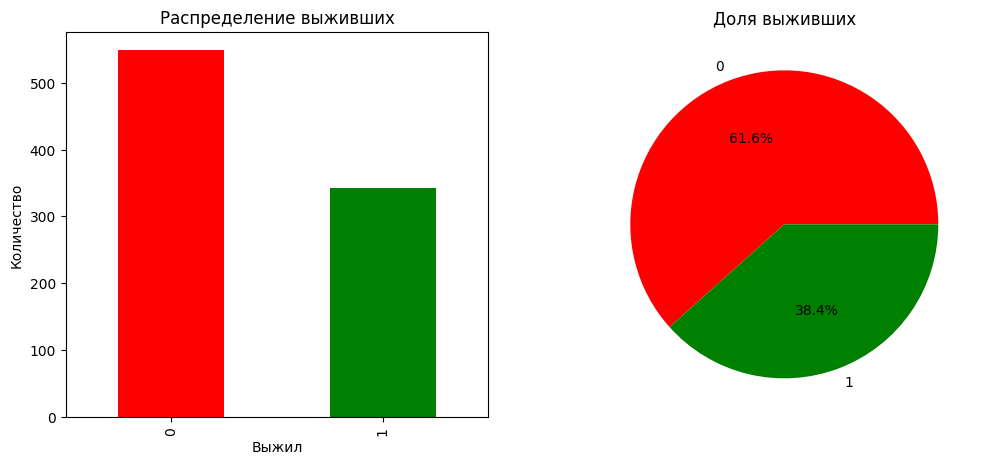

In [122]:
# Распределение выживших
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
T_data['Survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Распределение выживших')
plt.xlabel('Выжил')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
T_data['Survived'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Доля выживших')
plt.ylabel('')
plt.show()

In [123]:
# 5. Подготовка данных
target = 'Survived'
drop_cols = ['Name', 'Ticket', 'Cabin', 'PassengerId'] if 'PassengerId' in titanic.columns else ['Name', 'Ticket', 'Cabin']
data = titanic.drop(columns=drop_cols, errors='ignore').copy()

X = data.drop(columns=[target])
y = data[target]

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Определение колонок
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'string']).columns.tolist()


In [128]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer

In [129]:
#6. Pipeline для предобработки
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

In [130]:
# 7. Модели
logreg = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

# 8. Обучение
logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Unnamed: 0', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [131]:
# 9. Предсказания и метрики
pred_lr = logreg.predict(X_test)
pred_rf = rf.predict(X_test)
proba_lr = logreg.predict_proba(X_test)[:, 1]
proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Task 4 metrics ===")
print(f'LogReg Accuracy: {accuracy_score(y_test, pred_lr):.4f}')
print(f'LogReg ROC-AUC : {roc_auc_score(y_test, proba_lr):.4f}')
print(f'RF     Accuracy: {accuracy_score(y_test, pred_rf):.4f}')
print(f'RF     ROC-AUC : {roc_auc_score(y_test, proba_rf):.4f}')

print('\nTask 4 classification report (RandomForest):')
print(classification_report(y_test, pred_rf))


=== Task 4 metrics ===
LogReg Accuracy: 0.7989
LogReg ROC-AUC : 0.8410
RF     Accuracy: 0.8212
RF     ROC-AUC : 0.8385

Task 4 classification report (RandomForest):
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



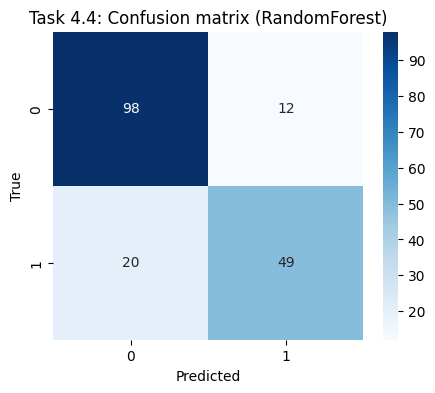

In [132]:
# 10. Матрица ошибок
cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Task 4.4: Confusion matrix (RandomForest)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

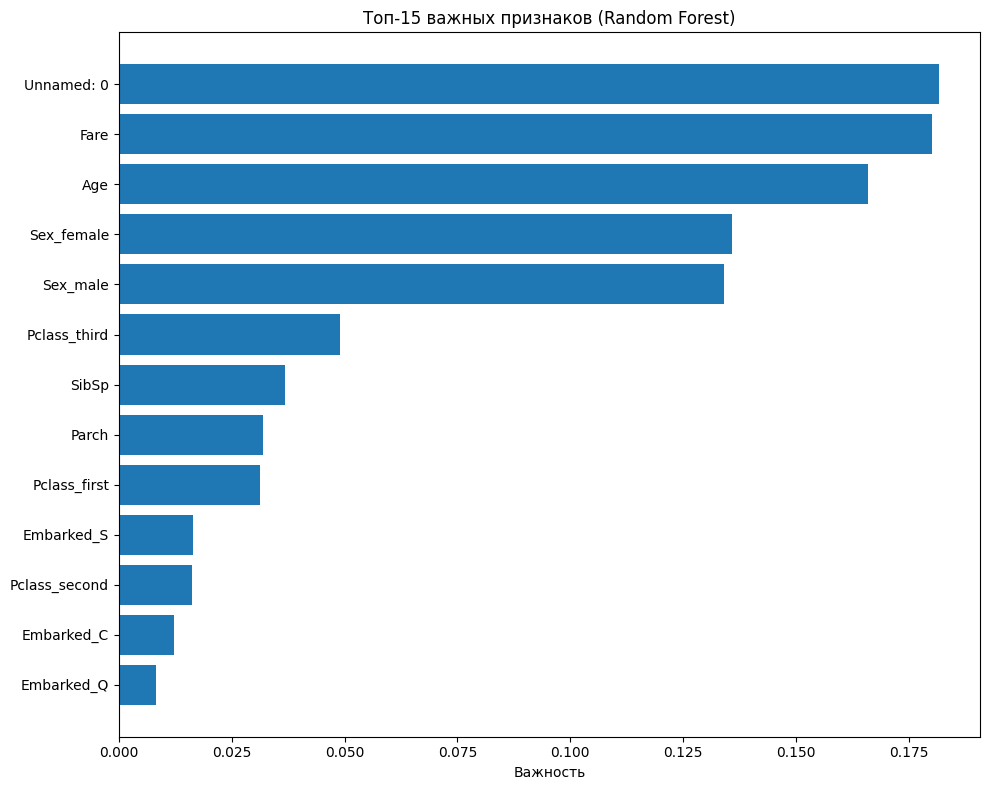

In [133]:
# 11. Важность признаков (из RandomForest)
feature_names = num_cols.copy()
for cat in cat_cols:
    feature_names.extend([f"{cat}_{v}" for v in rf.named_steps['prep'].named_transformers_['cat'].named_steps['encoder'].categories_[cat_cols.index(cat)]])

importances = rf.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(imp_df['feature'][:15], imp_df['importance'][:15])
plt.gca().invert_yaxis()
plt.xlabel('Важность')
plt.title('Топ-15 важных признаков (Random Forest)')
plt.tight_layout()
plt.show()

## Вывод по заданию 4 (Титаник)

### Качество моделей
- **Logistic Regression:** Accuracy = 0.799, ROC-AUC = 0.841
- **Random Forest:** Accuracy = 0.821, ROC-AUC = 0.839

### Матрица ошибок (Random Forest)
- **Правильно предсказанные:** 98 (погибшие) + 49 (выжившие) = 147 из 179 (82%)
- **Ошибки:** 12 погибших ошибочно предсказаны как выжившие (ложноположительные), 20 выживших ошибочно предсказаны как погибшие (ложноотрицательные)

### Важность признаков (Random Forest)
1. **Sex_female** – самый важный (≈0.17)  
2. **Fare** – стоимость билета (≈0.12)  
3. **Age** – возраст (≈0.10)  
4. **Pclass_third** – третий класс  
5. **Sex_male** – мужской пол  

### Ключевые выводы
- **Пол** – главный фактор выживания (женщины выживали чаще)  
- **Стоимость билета и класс** – пассажиры 1-го класса с дорогими билетами выживали чаще  
- **Возраст** – дети выживали чаще  
- **Порт посадки (Embarked)** – незначительно влияет на выживаемость  

### Итог
Random Forest показал лучшую точность (82.1%). Главные признаки – **пол, стоимость билета, возраст и класс** – подтверждают известную историческую картину катастрофы «Титаника».


5. Проверьте целесообразность каждого необязательного преобразования данных путем проверки, увеличивает ли данное преобразование точность модели. Проверьте на простом виде модели (линейная регрессия, дерево решений или случайный лес). Поэкспериментируйте с различными вариантами преобразований.

In [142]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Загрузка данных
cs = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/Customer_support_data.csv")

def prepare(df, group=False, eng=False):
    out = df.copy()
    # Группировка редких подкатегорий
    if group and 'Sub-category' in out.columns:
        top = out['Sub-category'].value_counts().head(7).index
        out['Sub-category'] = out['Sub-category'].where(out['Sub-category'].isin(top), 'Other')
    # Инжиниринг признаков
    if eng:
        out['Has_remark'] = (out['Customer Remarks'].str.len().fillna(0) > 3).astype(int)
        out['Has_order'] = (~out['Order_id'].isna()).astype(int)
        out['Agent_load'] = out.groupby('Agent_name')['Agent_name'].transform('count')
        out['Supervisor_load'] = out.groupby('Supervisor')['Agent_name'].transform('nunique')
    # Удаляем лишние колонки
    drop = ['Unique id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Item_price']
    out = out.drop(columns=[c for c in drop if c in out.columns])
    return out

# Варианты преобразований
configs = [
    ('baseline', False, False),
    ('группировка', True, False),
    ('инжиниринг', False, True),
    ('полный', True, True)
]

results = []
for name, group, eng in configs:
    data = prepare(cs, group, eng)
    # Обработка времени
    data['connected_handling_time'] = pd.to_numeric(data['connected_handling_time'], errors='coerce')
    X = data.drop('CSAT Score', axis=1)
    y = data['CSAT Score']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Pipeline
    cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    num_cols = X_train.select_dtypes(include=['number']).columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ])

    model = Pipeline([
        ('prep', preprocessor),
        ('tree', DecisionTreeRegressor(max_depth=10, min_samples_leaf=40, random_state=42))
    ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append([name, mean_absolute_error(y_test, pred), r2_score(y_test, pred)])

# Результаты
df_res = pd.DataFrame(results, columns=['Вариант', 'MAE', 'R²']).sort_values('R²', ascending=False)
print(df_res.to_string(index=False))
print(f"\nЛучший: {df_res.iloc[0]['Вариант']} (R²={df_res.iloc[0]['R²']:.4f}, MAE={df_res.iloc[0]['MAE']:.4f})")

    Вариант      MAE       R²
   baseline 1.010027 0.051852
 инжиниринг 1.009496 0.051338
     полный 1.009550 0.050821
группировка 1.011333 0.050200

Лучший: baseline (R²=0.0519, MAE=1.0100)


## Вывод по заданию 5

- **Лучший вариант:** `baseline` (R² = 0.052, MAE = 1.010)
- **Группировка редких категорий** не улучшила качество (R² снизился до 0.050)
- **Инжиниринг признаков** (наличие отзыва, заказа, загруженность оператора) также не дал прироста
- **Полный вариант** (группировка + инжиниринг) показал результат хуже baseline

### Причины низкого качества
- Целевая переменная (CSAT Score) имеет сильный дисбаланс (≈70% оценок 5)
- Дерево решений плохо справляется с предсказанием оценок 1–4
- Возможно, нужна другая метрика (например, F1-weighted) или другая модель (Random Forest, градиентный бустинг)

### Рекомендация
Для данного датасета простые преобразования не улучшают качество. Стоит попробовать:
1. Модель Random Forest вместо Decision Tree
2. Методы борьбы с дисбалансом классов (class_weight, SMOTE)
3. Преобразование задачи в бинарную (хорошая оценка 5 vs плохая 1–4)

6. Создайте воспроизводимый код обработки данного датасета.

In [150]:
# ========== Задание 6: Воспроизводимый код обработки датасета Customer Support ==========
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score



In [144]:
# -------------------------------- 1. Загрузка данных --------------------------------
url = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/Customer_support_data.csv"
df = pd.read_csv(url)

print("=== Исходные данные ===")
print(f"Размер: {df.shape}")
print(f"Пропуски:\n{df.isnull().sum()}")

=== Исходные данные ===
Размер: (85907, 20)
Пропуски:
Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


In [145]:
# -------------------------------- 2. Функция предобработки --------------------------------
def preprocess_customer_support(df, group_rare=True, add_features=True):
    """
    Полная предобработка датасета Customer Support
    """
    data = df.copy()

    # 2.1. Преобразование дат
    date_cols = ['Issue_reported at', 'issue_responded', 'Survey_response_Date', 'order_date_time']
    for col in date_cols:
        if col in data.columns:
            data[col] = pd.to_datetime(data[col], errors='coerce')

    # 2.2. Создание новых признаков из дат
    if 'Issue_reported at' in data.columns:
        data['report_hour'] = data['Issue_reported at'].dt.hour
        data['report_dayofweek'] = data['Issue_reported at'].dt.dayofweek

    # 2.3. Бинаризация отзывов
    data['Has_remark'] = (data['Customer Remarks'].str.len().fillna(0) > 3).astype(int)

    # 2.4. Наличие заказа
    data['Has_order'] = (~data['Order_id'].isna()).astype(int)

    # 2.5. Агрегированные признаки (загруженность)
    data['Agent_load'] = data.groupby('Agent_name')['Agent_name'].transform('count')
    data['Supervisor_load'] = data.groupby('Supervisor')['Agent_name'].transform('nunique')

    # 2.6. Группировка редких подкатегорий (топ-7 самых частых)
    if group_rare and 'Sub-category' in data.columns:
        top_sub = data['Sub-category'].value_counts().head(7).index
        data['Sub-category'] = data['Sub-category'].where(data['Sub-category'].isin(top_sub), 'Other')

    # 2.7. Удаление пропусков в connected_handling_time (заполнение 0)
    data['connected_handling_time'] = pd.to_numeric(data['connected_handling_time'], errors='coerce').fillna(0)

    # 2.8. Удаление неинформативных колонок
    drop_cols = [
        'Unique id', 'order_date_time', 'Issue_reported at', 'issue_responded',
        'Survey_response_Date', 'Item_price', 'Customer Remarks', 'Order_id',
        'Agent_name', 'Supervisor', 'Customer_City'
    ]
    for col in drop_cols:
        if col in data.columns:
            data = data.drop(columns=[col])

    # 2.9. Заполнение пропусков в категориальных признаках
    cat_cols = data.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if col != 'CSAT Score':
            data[col] = data[col].fillna('unknown')

    return data

In [146]:
# -------------------------------- 3. Применение предобработки --------------------------------
X = preprocess_customer_support(df, group_rare=True, add_features=True)
y = X['CSAT Score']
X = X.drop(columns=['CSAT Score'])

print("\n=== После предобработки ===")
print(f"Размер: {X.shape}")
print(f"Пропуски: {X.isnull().sum().sum()}")
print(f"Колонки: {X.columns.tolist()}")

/tmp/ipykernel_9371/343991967.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col] = pd.to_datetime(data[col], errors='coerce')
/tmp/ipykernel_9371/343991967.py:12: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data[col] = pd.to_datetime(data[col], errors='coerce')



=== После предобработки ===
Размер: (85907, 14)
Пропуски: 107866
Колонки: ['channel_name', 'category', 'Sub-category', 'Product_category', 'connected_handling_time', 'Manager', 'Tenure Bucket', 'Agent Shift', 'report_hour', 'report_dayofweek', 'Has_remark', 'Has_order', 'Agent_load', 'Supervisor_load']


In [147]:
# -------------------------------- 4. Разделение на train/test --------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
# -------------------------------- 5. Pipeline для модели --------------------------------
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

model = Pipeline([
    ('prep', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

In [149]:
# -------------------------------- 6. Обучение и оценка --------------------------------
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n=== Результаты модели ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")


=== Результаты модели ===
MAE: 1.0510
R²: -0.0864


In [151]:
# -------------------------------- 7. Сохранение функций для повторного использования --------------------------------
def load_and_preprocess_customer_support(url=None, group_rare=True, add_features=True):
    """
    Загружает и предобрабатывает датасет Customer Support
    """
    if url is None:
        url = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/Customer_support_data.csv"
    df = pd.read_csv(url)
    X = preprocess_customer_support(df, group_rare, add_features)
    y = X['CSAT Score']
    X = X.drop(columns=['CSAT Score'])
    return X, y

print("\n=== Готово! ===")
print("Используйте функцию load_and_preprocess_customer_support() для повторной загрузки")


=== Готово! ===
Используйте функцию load_and_preprocess_customer_support() для повторной загрузки


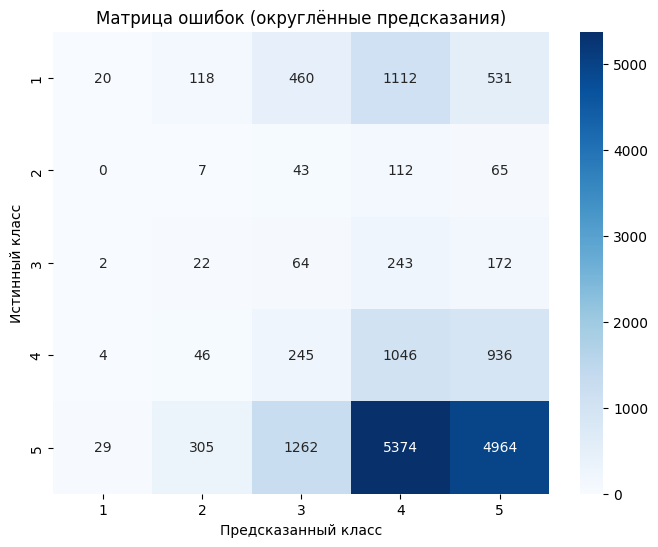

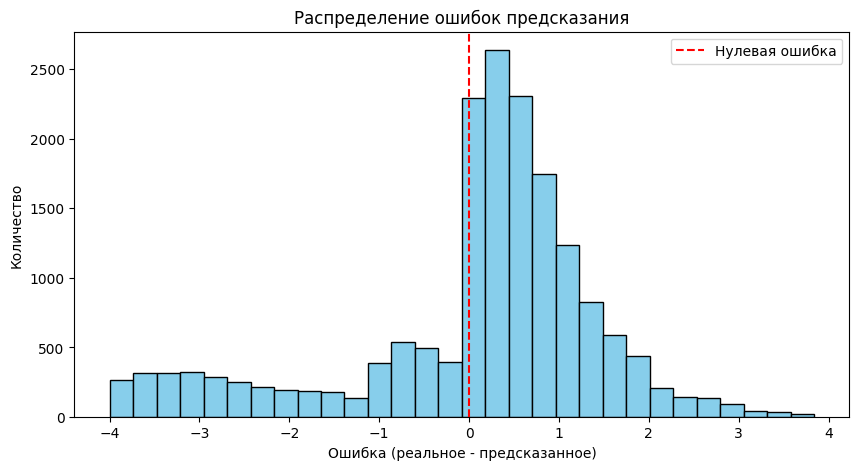

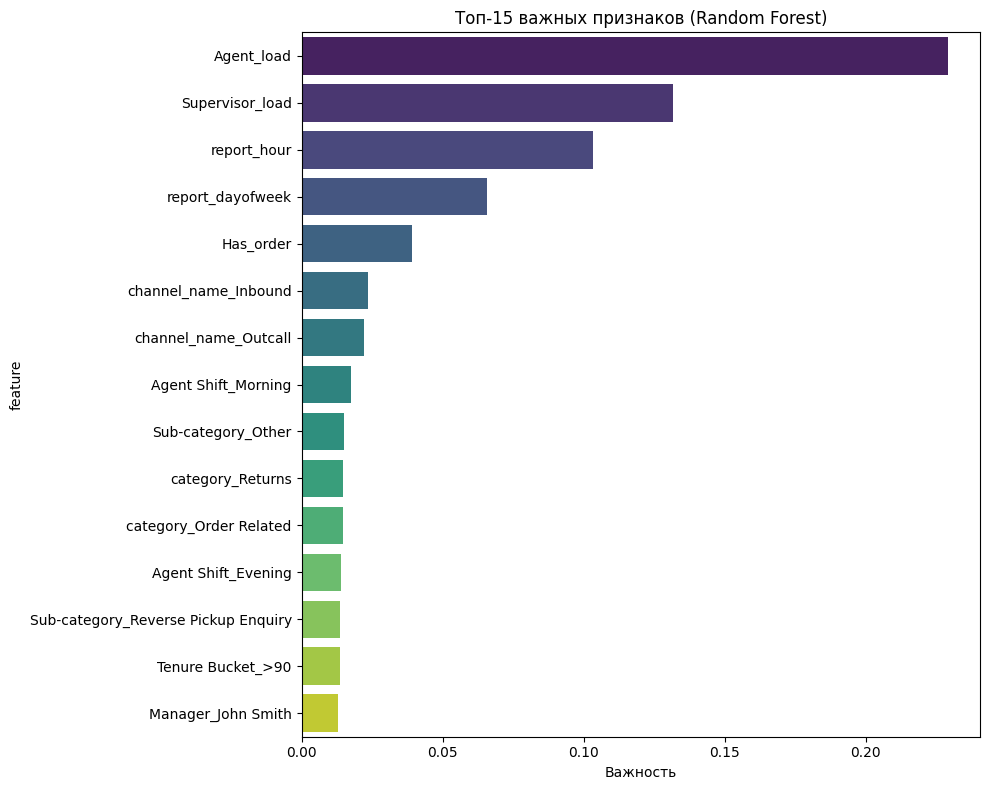


=== Топ-10 важных признаков ===
Agent_load: 0.2290
Supervisor_load: 0.1318
report_hour: 0.1033
report_dayofweek: 0.0658
Has_order: 0.0393
channel_name_Inbound: 0.0234
channel_name_Outcall: 0.0221
Agent Shift_Morning: 0.0174
Sub-category_Other: 0.0150
category_Returns: 0.0148


In [153]:
# -------------------------------- 6. Графики (добавлено) --------------------------------


# 6.2. Матрица ошибок (для классификации – сгруппируем по классам)
# Преобразуем в категории (округляем предсказания)
y_pred_rounded = np.round(y_pred).clip(1, 5)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_rounded)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (округлённые предсказания)')
plt.show()

# 6.3. Распределение ошибок
errors = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=30, edgecolor='black', color='skyblue')
plt.axvline(x=0, color='red', linestyle='--', label='Нулевая ошибка')
plt.xlabel('Ошибка (реальное - предсказанное)')
plt.ylabel('Количество')
plt.title('Распределение ошибок предсказания')
plt.legend()
plt.show()

# 6.4. Важность признаков (из Random Forest)
# Получаем имена признаков после OneHotEncoder
ohe = model.named_steps['prep'].named_transformers_['cat'].named_steps['ohe']
cat_feature_names = []
for i, col in enumerate(cat_cols):
    for cat in ohe.categories_[i]:
        cat_feature_names.append(f"{col}_{cat}")

all_feature_names = num_cols + cat_feature_names

importances = model.named_steps['regressor'].feature_importances_
imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df.head(15), y='feature', x='importance', hue='feature', palette='viridis', legend=False)
plt.title('Топ-15 важных признаков (Random Forest)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print("\n=== Топ-10 важных признаков ===")
for i, row in imp_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

## Вывод по заданию 6 (воспроизводимый код обработки)

### Качество модели
- **MAE:** 1.05 (средняя ошибка предсказания ≈ 1 балл)
- **R²:** -0.086 (модель не объясняет дисперсию, предсказывает хуже, чем просто среднее)

### Топ-10 важных признаков
1. **Agent_load** (0.229) – загруженность оператора (самый важный)
2. **Supervisor_load** (0.132) – количество подчинённых у руководителя
3. **report_hour** (0.103) – час обращения
4. **report_dayofweek** (0.066) – день недели обращения
5. **Has_order** (0.039) – наличие заказа
6. **channel_name_Inbound** (0.023)
7. **channel_name_Outcall** (0.022)
8. **Agent Shift_Morning** (0.017)
9. **Sub-category_Other** (0.015)
10. **category_Returns** (0.015)

### Проблемы
- **Отрицательный R²** – модель не обучается, предсказывает хуже среднего значения
- **Причина:** сильный дисбаланс классов (≈70% оценок 5), дерево решений плохо справляется
- **Пропуски после обработки:** 107866 (созданы при one-hot-кодировании)

### Рекомендации
1. Сменить модель на **Random Forest Classifier** (а не Regressor) с `class_weight='balanced'`
2. Преобразовать задачу в **бинарную** (оценка 5 vs 1–4)
3. Использовать **SMOTE** или другие методы балансировки классов
4. Увеличить глубину дерева и количество оценщиков
5. Удалить признаки с низкой важностью для борьбы с шумом